<a href="https://colab.research.google.com/github/nkreuzer26/Hist1354_Final/blob/main/AHDI_Masterlist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AHDI Synthetic Control Analysis

## Augmented Human Development Index: Five Latin American Case Studies

This notebook applies the Synthetic Control Method (SCM) to estimate the quality of life impact
of US-backed military interventions in Latin America. The outcome variable is the
**Augmented Human Development Index (AHDI)**, a composite measure integrating health
(life expectancy), education (literacy and enrollment), income (GDP per capita), and
political freedom on a 0-1 scale.

Five case studies are examined: Chile (1973), Brazil (1964), Dominican Republic (1965),
Ecuador (1963), and Argentina (1976).

## Context: From GDP per Capita to AHDI

The prior notebook (`NK_GDPPC_Masterlist.ipynb`) estimates the output effect of each
intervention using annual GDP per capita data from the Maddison Project. GDP captures
economic production but says nothing about how gains or losses were distributed, or how
the intervention affected health, education, and political rights.

AHDI addresses this by combining four dimensions of human welfare into a single index.
An intervention that raised GDP while suppressing political freedoms and degrading public
services would show a positive GDP gap but a negative AHDI gap. The two analyses are both useful.
GDP per capita captures economic output AHDI captures broader welfare/quality of life.

The SCM methodology is identical across both notebooks. The main structural difference is that AHDI
is measured every five years, which means each case study has only three to six pre-treatment
observations. Donor pools are made using the same exclusion criteria as the GDP analysis (subject to data availability).

## Shared Setup

The cells below load all four data sources used across the five case studies.
Run this section once before any individual case study.

- `augmented-human-development-index.csv`: AHDI by country and year (quinquennial)
- `mpd2023_web.xlsx`: Maddison Project GDP per capita, used for donor screening and predictors
- `pwt110.xlsx`: Penn World Table human capital (`hc`) and investment share (`csh_i`)
- `BL2013_MF2599_v2.2.xls`: Barro-Lee average years of total schooling (quinquennial)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Install pysyncon if not present
try:
    from pysyncon import Dataprep, Synth
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "pysyncon", "-q"], check=True)
    from pysyncon import Dataprep, Synth

# Load AHDI data
ahdi_raw = pd.read_csv("augmented-human-development-index.csv")
ahdi_value_col = [
    c for c in ahdi_raw.columns
    if c not in ["Entity", "Code", "Year",
                 "World region according to OWID",
                 "Augmented Human Development Index (AHDI) (Annotations)"]
][0]
ahdi_data = ahdi_raw.rename(columns={
    "Entity": "country", "Year": "year", ahdi_value_col: "ahdi"
})[['country', 'year', 'ahdi']].copy()

# Load Maddison Project Database
maddison_full = pd.read_excel("mpd2023_web.xlsx", sheet_name="Full data")

# Load Penn World Table 11.0
pwt_data = pd.read_excel("pwt110.xlsx", sheet_name="Data")

# Load Barro-Lee educational attainment
# Two-condition match ensures we get average schooling years, not the 'No Schooling' share
schooling_raw = pd.read_excel("BL2013_MF2599_v2.2.xls", sheet_name="Sheet1", header=7)
schooling_raw["Country"] = schooling_raw["Country"].ffill()
schooling_raw = schooling_raw[schooling_raw["Country"].notna()].copy()
school_col = next(
    (col for col in schooling_raw.columns
     if "avg" in col.lower() and "schooling" in col.lower()),
    None
)
if school_col is None:
    raise ValueError("Barro-Lee schooling column not found")
schooling_data = schooling_raw.rename(columns={
    "Country": "country", "Year": "year", school_col: "school_years"
})[['country', 'year', 'school_years']].copy()

# Edit Barro-Lee country names to match Maddison
BL_TO_MADDISON = {
    "Dominican Rep.": "Dominican Republic",
    "Korea, Rep.": "Republic of Korea",
    "Venezuela, RB": "Venezuela",
    "Iran, Islamic Rep.": "Iran",
    "Egypt, Arab Rep.": "Egypt",
    "Syrian Arab Rep.": "Syrian Arab Republic",
    "Hong Kong, China": "Hong Kong",
    "Trinidad &Tobago": "Trinidad and Tobago",
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Congo, Dem. Rep.": "Democratic Republic of the Congo",
    "Congo, Rep.": "Congo",
    "Central African Rep.": "Central African Republic",
    "Lao PDR": "Laos",
    "Gambia, The": "Gambia",
}
schooling_data["country"] = schooling_data["country"].replace(BL_TO_MADDISON)

def has_all_preds(panel, country, cols, years):
    """Check if country has non-null values for all cols at all specified years."""
    rows = panel[(panel["unit"] == country) & (panel["year"].isin(years))]
    return all(rows[col].notna().all() for col in cols if col in panel.columns)

print(f"AHDI: {ahdi_data['country'].nunique()} countries")
print(f"Maddison: {maddison_full['country'].nunique()} countries")
print(f"PWT: {pwt_data['country'].nunique()} countries")
print(f"Barro-Lee: {schooling_data['country'].nunique()} countries, column: '{school_col}'")

AHDI: 174 countries
Maddison: 169 countries
PWT: 185 countries
Barro-Lee: 146 countries, column: 'Avg. Years of Total Schooling'


---

## Chile 1973

On September 11, 1973, General Augusto Pinochet led a US-backed military coup that
overthrew the elected government of Salvador Allende. The coup ended Chile's longest
uninterrupted democratic period and inaugurated seventeen years of authoritarian rule.
The new government suspended political rights, dissolved congress, and implemented
sweeping free-market restructuring under the influence of the "Chicago Boys."

The AHDI analysis examines how the coup affected Chile's composite welfare trajectory.
Chile's AHDI had been rising steadily from 1950 to 1970 (from 0.27 to 0.36). The
post-1973 path reflects the economic disruption of the early Pinochet years and
the suppression of political rights captured in the freedom component of AHDI. The
return toward higher AHDI values after the mid-1980s roughly coincides with gradual
democratic opening and the 1990 restoration of civilian government.

The donor pool and exclusion criteria follow the same logic as the GDP per capita
analysis for Chile.

In [ ]:
# Chile 1973 case study parameters
TREATED_COUNTRY_CL = "Chile"
INTERVENTION_YEAR_CL = 1973
PRE_TREATMENT_START_CL = 1950
PRE_TREATMENT_END_CL = 1972

# AHDI is quinquennial; 5 pre-treatment and 6 post-treatment time points
AHDI_PRE_YEARS_CL  = [1950, 1955, 1960, 1965, 1970]
AHDI_POST_YEARS_CL = [1975, 1980, 1985, 1990, 1995, 2000]
AHDI_ALL_YEARS_CL  = AHDI_PRE_YEARS_CL + AHDI_POST_YEARS_CL

# GDP screening: 25%-225% of Chile's 1972 GDP per capita
GDP_FLOOR_CL = 0.25
GDP_CEIL_CL  = 2.25

### Donor Pool Construction

The donor pool is built in three steps. First, countries are screened by their 1972 GDP
per capita: only those between 25% and 225% of Chile's level are considered. Second,
countries with confounding characteristics are excluded, this covers other treated
units, authoritarian regimes, oil economies, Asian Tigers, micro-economies, and
non-Atlantic developing countries. Third only countries with complete AHDI data across
all required quinquennial years and complete annual Maddison GDP coverage are retained.

Countries marked with LIMITATION in the notes below have partial confounders but are
retained because the donor pool would otherwise be too small.

In [ ]:
EXCLUSIONS_CL = {
    "Chile": "Treated country",
    "Brazil": "Other treated unit",
    "Dominican Republic": "Other treated unit",
    "Ecuador": "Other treated unit",
    "Argentina": "Other treated unit",
    "Uruguay": "Bordaberry coup June 1973",
    "Peru": "Velasco military 1968-1975",
    "Cuba": "Castro socialist economy",
    "Haiti": "Duvalier dictatorship",
    "Nicaragua": "Somoza dynastic rule",
    "Guatemala": "Military government; civil war",
    "El Salvador": "Military regime",
    "Honduras": "Lopez Arellano military; chronic instability",
    "Panama": "Torrijos military; Canal Zone",
    "Paraguay": "Stroessner dictatorship",
    "Bolivia": "Banzer coup 1971",
    "Bolivia (Plurinational State of)": "Banzer coup 1971",
    "Thailand": "Military regimes",
    "Indonesia": "Suharto regime",
    "Viet Nam": "War; reunification 1975",
    "South Africa": "Apartheid",
    "Algeria": "One-party state",
    "Egypt": "Arab Socialism",
    "Syrian Arab Republic": "Ba'ath regime",
    "Syria": "Ba'ath regime",
    "Romania": "Communist",
    "Bulgaria": "Soviet satellite",
    "Hungary": "Soviet satellite",
    "Albania": "Communist",
    "Poland": "Soviet satellite",
    "Former Yugoslavia": "Socialist",
    "Yugoslavia": "Socialist",
    "Croatia": "Socialist Yugoslavia",
    "Slovenia": "Socialist Yugoslavia",
    "Bosnia and Herzegovina": "Post-Yugoslav",
    "Serbia": "Post-Yugoslav",
    "Montenegro": "Post-Yugoslav",
    "Macedonia": "Post-Yugoslav",
    "TFYR of Macedonia": "Post-Yugoslav",
    "Former USSR": "Soviet",
    "Russian Federation": "USSR",
    "Czechoslovakia": "Socialist",
    "Czech Republic": "Former Czechoslovakia",
    "Seychelles": "Socialist",
    "Congo": "Socialist 1969-1992",
    "Tunisia": "Single-party",
    "Yemen": "Socialist 1967-1990",
    "Venezuela (Bolivarian Republic of)": "OPEC; oil",
    "Venezuela": "OPEC; oil",
    "Libya": "Oil; Gaddafi",
    "Iran (Islamic Republic of)": "Oil; Revolution",
    "Iran": "Oil; Revolution",
    "Gabon": "Oil",
    "Iraq": "Oil; Ba'athist",
    "Bahrain": "Oil",
    "Saudi Arabia": "Oil",
    "Kuwait": "Oil; OPEC",
    "Trinidad and Tobago": "Oil; 1973 windfall",
    "Equatorial Guinea": "Oil",
    "Oman": "Oil",
    "Nigeria": "Oil; military coups",
    "Republic of Korea": "Asian Tiger; Park military",
    "Taiwan, Province of China": "Asian Tiger",
    "Taiwan": "Asian Tiger",
    "Malaysia": "Tiger Cub",
    "Singapore": "City-state Tiger",
    "China, Hong Kong SAR": "City-state",
    "Hong Kong": "City-state",
    "Puerto Rico": "US territory",
    "Barbados": "Small island",
    "Cyprus": "Small island; 1974 partition",
    "Mauritius": "Small island",
    "Malta": "Small island",
    "Djibouti": "French territory",
    "Saint Lucia": "Micro-economy",
    "Dominica": "Micro-island",
    "Jamaica": "Manley socialism 1972-1980",
    "Iceland": "Micro-economy",
    "Luxembourg": "Micro-economy",
    "Lebanon": "Civil war",
    "Sri Lanka": "Tamil insurgency",
    "Liberia": "Coup 1980",
    "Namibia": "UNITA conflict",
    "Swaziland": "ANC conflicts",
    "Angola": "Colonial/civil war",
    "Cambodia": "Khmer Rouge",
    "Sudan": "Civil wars",
    "Sudan (Former)": "Civil war",
    "Palestine": "Incomplete",
    "State of Palestine": "Incomplete",
    "Jordan": "Incomplete",
    "Israel": "Yom Kippur War 1973",
    "Afghanistan": "Incomplete",
    "Benin": "Non-Atlantic",
    "Togo": "Non-Atlantic",
    "Niger": "Non-Atlantic",
    "Burkina Faso": "Non-Atlantic",
    "Mali": "Non-Atlantic",
    "Mauritania": "Non-Atlantic",
    "Gambia": "Non-Atlantic",
    "Sierra Leone": "Non-Atlantic",
    "Guinea": "Non-Atlantic",
    "Guinea-Bissau": "Non-Atlantic",
    "Côte d'Ivoire": "Non-Atlantic",
    "Cameroon": "Non-Atlantic",
    "Central African Republic": "Non-Atlantic",
    "Chad": "Non-Atlantic",
    "Uganda": "Non-Atlantic",
    "Kenya": "Non-Atlantic",
    "Tanzania": "Non-Atlantic",
    "United Republic of Tanzania": "Non-Atlantic",
    "U.R. of Tanzania: Mainland": "Non-Atlantic",
    "Zambia": "Non-Atlantic",
    "Zimbabwe": "Non-Atlantic",
    "Malawi": "Non-Atlantic",
    "Lesotho": "Non-Atlantic",
    "Rwanda": "Non-Atlantic",
    "Burundi": "Non-Atlantic",
    "Madagascar": "Non-Atlantic",
    "Ethiopia": "Non-Atlantic",
    "Somalia": "Non-Atlantic",
    "Eritrea": "Non-Atlantic",
    "Mozambique": "Non-Atlantic",
    "Ghana": "Non-Atlantic",
    "Senegal": "Non-Atlantic",
    "Botswana": "Non-Atlantic",
    "Comoros": "Non-Atlantic",
    "Democratic Republic of the Congo": "Non-Atlantic",
    "D.R. of the Congo": "Non-Atlantic",
    "Sao Tome and Principe": "Non-Atlantic",
    "Cabo Verde": "Non-Atlantic",
    "India": "Non-Atlantic",
    "Pakistan": "Non-Atlantic",
    "Nepal": "Non-Atlantic",
    "Bangladesh": "Non-Atlantic",
    "Myanmar": "Non-Atlantic",
    "Philippines": "Non-Atlantic; Marcos",
    "China": "Non-Atlantic; Maoist",
    "Mongolia": "Non-Atlantic",
    "Lao People's DR": "Non-Atlantic",
}

RETAINED_NOTES_CL = {
    "Colombia": "Democratic; key LA comparator.",
    "Mexico": "PRI but market economy; key LA comparator.",
    "Costa Rica": "Democratic throughout; LA benchmark.",
    "Spain": "Franco through 1975; democratic transition. LIMITATION.",
    "Portugal": "Caetano through 1974; Carnation Revolution. LIMITATION.",
    "Greece": "Military junta 1967-1974. LIMITATION.",
    "Ireland": "Democratic throughout; mid-income European.",
    "Italy": "Democratic throughout; Mediterranean comparator.",
    "Japan": "Democratic throughout; high-growth.",
    "Austria": "Democratic throughout.",
    "Finland": "Democratic throughout.",
    "Turkey": "Democratic 1961-71, military 1971-73. LIMITATION.",
    "Morocco": "Non-LA Atlantic comparator. LIMITATION.",
}

# GDP screening at the last pre-treatment year
maddison_cl = maddison_full[
    (maddison_full["year"] >= PRE_TREATMENT_START_CL) &
    (maddison_full["year"] <= 2000)
].copy()

cl_gdp_1972 = maddison_cl.loc[
    (maddison_cl["country"] == TREATED_COUNTRY_CL) &
    (maddison_cl["year"] == PRE_TREATMENT_END_CL), "gdppc"
].values[0]

gdp_screen_cl = (
    maddison_cl[maddison_cl["year"] == PRE_TREATMENT_END_CL][['country', 'gdppc']]
    .dropna(subset=['gdppc']).copy()
)
gdp_screen_cl['ratio'] = gdp_screen_cl['gdppc'] / cl_gdp_1972

candidates_cl = gdp_screen_cl[
    (gdp_screen_cl['ratio'] >= GDP_FLOOR_CL) &
    (gdp_screen_cl['ratio'] <= GDP_CEIL_CL) &
    (~gdp_screen_cl['country'].isin(EXCLUSIONS_CL))
]['country'].tolist()

print(f"Chile 1972 GDP: ${cl_gdp_1972:,.0f}")
print(f"Candidates after GDP screening and exclusions: {len(candidates_cl)}")

Chile 1972 GDP: $8,520
Candidates after GDP screening and exclusions: 18


In [ ]:
# Keep only countries with complete AHDI and annual Maddison GDP coverage
maddison_annual_years = set(range(PRE_TREATMENT_START_CL, 2001))
final_donor_pool_cl = []
dropped_cl = []

for c in candidates_cl:
    reasons = []

    # Need all AHDI time points
    c_ahdi = ahdi_data[
        (ahdi_data['country'] == c) & (ahdi_data['year'].isin(AHDI_ALL_YEARS_CL))
    ]
    if len(c_ahdi) < len(AHDI_ALL_YEARS_CL):
        reasons.append(f"AHDI {len(c_ahdi)}/{len(AHDI_ALL_YEARS_CL)} points")

    # Need reasonably complete annual Maddison GDP
    c_gdp = maddison_cl[
        (maddison_cl['country'] == c) & (maddison_cl['year'].isin(maddison_annual_years))
    ].dropna(subset=['gdppc'])
    if len(c_gdp) < len(maddison_annual_years):
        reasons.append(f"Maddison {len(c_gdp)}/{len(maddison_annual_years)} years")

    if reasons:
        dropped_cl.append((c, reasons))
    else:
        final_donor_pool_cl.append(c)

if dropped_cl:
    print(f"Dropped for incomplete data ({len(dropped_cl)}):")
    for c, reasons in dropped_cl:
        print(f"  {c}: {'; '.join(reasons)}")

donor_units_cl = sorted(final_donor_pool_cl)
countries_of_interest_cl = [TREATED_COUNTRY_CL] + donor_units_cl

print(f"\nFinal donor pool: {len(donor_units_cl)} countries")
for c in donor_units_cl:
    gdp_val = gdp_screen_cl.loc[gdp_screen_cl['country'] == c, 'gdppc'].values[0]
    note = f"  ({RETAINED_NOTES_CL[c]})" if c in RETAINED_NOTES_CL else ""
    print(f"  {c}: ${gdp_val:,.0f}{note}")


Final donor pool: 18 countries
  Austria: $17,169  (Democratic throughout.)
  Belgium: $18,336
  Colombia: $5,348  (Democratic; key LA comparator.)
  Costa Rica: $6,564  (Democratic throughout; LA benchmark.)
  Finland: $16,654  (Democratic throughout.)
  Germany: $18,301
  Greece: $11,795  (Military junta 1967-1974. LIMITATION.)
  Ireland: $10,621  (Democratic throughout; mid-income European.)
  Italy: $16,035  (Democratic throughout; Mediterranean comparator.)
  Japan: $17,110  (Democratic throughout; high-growth.)
  Mexico: $7,256  (PRI but market economy; key LA comparator.)
  Morocco: $2,660  (Non-LA Atlantic comparator. LIMITATION.)
  New Zealand: $18,889
  Norway: $17,409
  Portugal: $10,130  (Caetano through 1974; Carnation Revolution. LIMITATION.)
  Spain: $10,788  (Franco through 1975; democratic transition. LIMITATION.)
  Turkey: $4,929  (Democratic 1961-71, military 1971-73. LIMITATION.)
  United Kingdom: $18,002


### Building the Analysis Panel

The long-format panel merges AHDI, Maddison GDP, PWT human capital and investment, and
Barro-Lee schooling at the quinquennial AHDI time points. This panel feeds directly into
pysyncon's `Dataprep`.

Investment (`csh_i`) is included as a predictor only if Chile's pre-treatment mean is
plausibly below 45% of GDP. PWT investment values above that threshold typically indicate
data anomalies.

In [ ]:
# Start from AHDI at all required time points for Chile and donors
ahdi_subset_cl = ahdi_data[
    (ahdi_data['country'].isin(countries_of_interest_cl)) &
    (ahdi_data['year'].isin(AHDI_ALL_YEARS_CL))
].copy().rename(columns={'country': 'unit'})

# Maddison GDP at AHDI time points
madd_merge_cl = maddison_cl[
    (maddison_cl['country'].isin(countries_of_interest_cl)) &
    (maddison_cl['year'].isin(AHDI_ALL_YEARS_CL))
][['country', 'year', 'gdppc']].rename(columns={'country': 'unit'})

# PWT: human capital and investment share
pwt_merge_cl = pwt_data[
    (pwt_data['country'].isin(countries_of_interest_cl)) &
    (pwt_data['year'].isin(AHDI_ALL_YEARS_CL))
][['country', 'year', 'hc', 'csh_i']].rename(columns={'country': 'unit'})

# Barro-Lee: average years of schooling
bl_merge_cl = schooling_data[
    (schooling_data['country'].isin(countries_of_interest_cl)) &
    (schooling_data['year'].isin(AHDI_ALL_YEARS_CL))
][['country', 'year', 'school_years']].rename(columns={'country': 'unit'})

panel_long_cl = (
    ahdi_subset_cl
    .merge(madd_merge_cl, on=['unit', 'year'], how='left')
    .merge(pwt_merge_cl, on=['unit', 'year'], how='left')
    .merge(bl_merge_cl, on=['unit', 'year'], how='left')
)

# Check whether Chile's investment rate is plausible for inclusion
cl_pre_rows = panel_long_cl[
    (panel_long_cl['unit'] == TREATED_COUNTRY_CL) &
    (panel_long_cl['year'].isin(AHDI_PRE_YEARS_CL))
]
cl_inv_mean = cl_pre_rows['csh_i'].dropna().mean()
INCLUDE_INVESTMENT_CL = pd.notna(cl_inv_mean) and cl_inv_mean <= 0.45

print(f"Panel shape: {panel_long_cl.shape}")
print(f"Columns: {list(panel_long_cl.columns)}")
print(f"Chile investment mean: {cl_inv_mean:.3f} -> {'included' if INCLUDE_INVESTMENT_CL else 'excluded'}")

Panel shape: (209, 7)
Columns: ['unit', 'year', 'ahdi', 'gdppc', 'hc', 'csh_i', 'school_years']
Chile investment mean: 0.121 -> included


### Fitting the Synthetic Control

Following the Basque Country example (Abadie and Gardeazabal 2003), the AHDI outcome
variable is included in `special_predictors` as sub-period level averages. This ensures
the optimizer matches Chile's AHDI levels.vThe `time_optimize_ssr` argument then handles
trajectory matching across all pre-treatment time points.

The model is fit using Nelder-Mead optimization with equal initial weights. Donors
missing any required variable at any pre-treatment year are dropped before fitting.

In [ ]:
# Identify which pre-treatment AHDI years have each variable for Chile
pre_rows_cl = panel_long_cl[
    (panel_long_cl['unit'] == TREATED_COUNTRY_CL) &
    (panel_long_cl['year'].isin(AHDI_PRE_YEARS_CL))
]
hc_years_cl = sorted(pre_rows_cl[pre_rows_cl['hc'].notna()]['year'].tolist())
bl_years_cl = sorted(pre_rows_cl[pre_rows_cl['school_years'].notna()]['year'].tolist())

# AHDI sub-period averages are included as level-matching predictors (Basque example)
special_predictors_cl = [
    ('ahdi',         [1950, 1955],       'mean'),
    ('ahdi',         [1960, 1965, 1970], 'mean'),
    ('gdppc',        [1950, 1955],       'mean'),
    ('gdppc',        [1960, 1965, 1970], 'mean'),
    ('hc',           hc_years_cl,        'mean'),
    ('school_years', bl_years_cl,        'mean'),
]
if INCLUDE_INVESTMENT_CL:
    inv_years_cl = sorted(pre_rows_cl[pre_rows_cl['csh_i'].notna()]['year'].tolist())
    if inv_years_cl:
        special_predictors_cl.append(('csh_i', inv_years_cl, 'mean'))

# Drop donors missing any required variable at any pre-treatment year
required_cols_cl = ['ahdi', 'gdppc', 'hc', 'school_years']
if INCLUDE_INVESTMENT_CL:
    required_cols_cl.append('csh_i')
donor_units_cl = [
    c for c in donor_units_cl
    if has_all_preds(panel_long_cl, c, required_cols_cl, AHDI_PRE_YEARS_CL)
]

dataprep_cl = Dataprep(
    foo=panel_long_cl,
    predictors=[],
    predictors_op='mean',
    time_predictors_prior=AHDI_PRE_YEARS_CL,
    special_predictors=special_predictors_cl,
    dependent='ahdi',
    unit_variable='unit',
    time_variable='year',
    treatment_identifier=TREATED_COUNTRY_CL,
    controls_identifier=donor_units_cl,
    time_optimize_ssr=AHDI_PRE_YEARS_CL,
)

synth_cl = Synth()
synth_cl.fit(dataprep=dataprep_cl, optim_method='Nelder-Mead', optim_initial='equal')

# Extract donor weights -- handle different return types across pysyncon versions
weights_raw_cl = synth_cl.weights(round=4)
if isinstance(weights_raw_cl, pd.Series):
    w_dict_cl = weights_raw_cl.to_dict()
elif isinstance(weights_raw_cl, pd.DataFrame):
    w_dict_cl = {row.iloc[0]: float(row.iloc[1]) for _, row in weights_raw_cl.iterrows()}
else:
    w_dict_cl = {donor_units_cl[k]: float(weights_raw_cl[k]) for k in range(len(donor_units_cl))}

donor_weights_cl = pd.Series(w_dict_cl).sort_values(ascending=False)
nonzero_cl = donor_weights_cl[donor_weights_cl > 0.001]
print('Donor weights (nonzero):')
for c, w in nonzero_cl.items():
    print(f'  {c}: {w:.4f} ({w*100:.1f}%)')
print(f'Weight sum: {donor_weights_cl.sum():.4f}')

Donor weights (nonzero):
  Colombia: 0.4159 (41.6%)
  Ireland: 0.2317 (23.2%)
  New Zealand: 0.2058 (20.6%)
  Morocco: 0.1301 (13.0%)
  Spain: 0.0165 (1.7%)
Weight sum: 1.0000


### Pre-treatment Fit

The table below compares Chile's actual AHDI to the synthetic counterpart at each
quinquennial time point. Pre-treatment RMSPE and correlation measure how well the
synthetic control tracks Chile before the 1973 coup.

In [ ]:
# Build wide outcome panel for diagnostics and plotting
outcome_panel_cl = panel_long_cl.pivot_table(
    index='year', columns='unit', values='ahdi'
).reindex(AHDI_ALL_YEARS_CL)

actual_cl = outcome_panel_cl[TREATED_COUNTRY_CL].values

# Synthetic series: weighted sum of donor trajectories
synth_vals_cl = np.zeros(len(AHDI_ALL_YEARS_CL))
for c, w in w_dict_cl.items():
    if w > 1e-6 and c in outcome_panel_cl.columns:
        synth_vals_cl += w * outcome_panel_cl.loc[AHDI_ALL_YEARS_CL, c].values

gap_cl = actual_cl - synth_vals_cl

# Pre-treatment fit metrics
pre_idx_cl  = [i for i, y in enumerate(AHDI_ALL_YEARS_CL) if y in AHDI_PRE_YEARS_CL]
post_idx_cl = [i for i, y in enumerate(AHDI_ALL_YEARS_CL) if y in AHDI_POST_YEARS_CL]
pre_actual_cl = actual_cl[pre_idx_cl]
pre_synth_cl  = synth_vals_cl[pre_idx_cl]

rmspe_pre_cl = np.sqrt(np.mean((pre_actual_cl - pre_synth_cl) ** 2))
corr_pre_cl  = np.corrcoef(pre_actual_cl, pre_synth_cl)[0, 1] if len(pre_actual_cl) > 2 else np.nan
avg_gap_post_cl = np.mean(gap_cl[post_idx_cl])

print(f"{'Year':>6}  {'Actual':>8}  {'Synthetic':>9}  {'Gap':>8}  {'Period':>6}")
print('-' * 50)
for i, y in enumerate(AHDI_ALL_YEARS_CL):
    period = 'PRE' if y in AHDI_PRE_YEARS_CL else 'POST'
    print(f"{y:>6}  {actual_cl[i]:>8.4f}  {synth_vals_cl[i]:>9.4f}  {gap_cl[i]:>+8.4f}  {period:>6}")

print(f"\nPre-treatment RMSPE:       {rmspe_pre_cl:.6f}")
if np.isfinite(corr_pre_cl):
    print(f"Pre-treatment correlation: {corr_pre_cl:.4f}")
print(f"Avg post-treatment gap:    {avg_gap_post_cl:+.4f} AHDI units")

  Year    Actual  Synthetic       Gap  Period
--------------------------------------------------
  1950    0.2684     0.2646   +0.0038     PRE
  1955    0.2762     0.2864   -0.0102     PRE
  1960    0.3105     0.3192   -0.0087     PRE
  1965    0.3344     0.3329   +0.0015     PRE
  1970    0.3583     0.3473   +0.0110     PRE
  1975    0.1982     0.3709   -0.1727    POST
  1980    0.2295     0.3868   -0.1573    POST
  1985    0.2476     0.4117   -0.1642    POST
  1990    0.4866     0.4316   +0.0550    POST
  1995    0.5564     0.4657   +0.0906    POST
  2000    0.5929     0.4924   +0.1006    POST

Pre-treatment RMSPE:       0.007954
Pre-treatment correlation: 0.9761
Avg post-treatment gap:    -0.0413 AHDI units


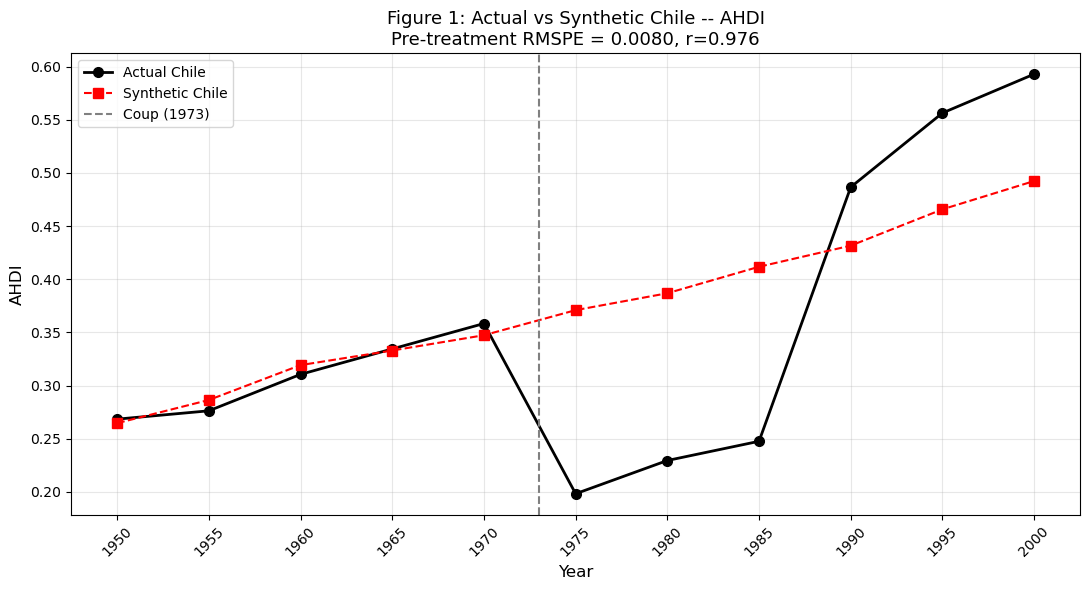

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(AHDI_ALL_YEARS_CL, actual_cl, 'k-o', markersize=7, linewidth=2,
        label='Actual Chile')
ax.plot(AHDI_ALL_YEARS_CL, synth_vals_cl, 'r--s', markersize=7, linewidth=1.5,
        label='Synthetic Chile')
ax.axvline(x=INTERVENTION_YEAR_CL, color='gray', linestyle='--',
           linewidth=1.5, label=f'Coup ({INTERVENTION_YEAR_CL})')

corr_str = f', r={corr_pre_cl:.3f}' if np.isfinite(corr_pre_cl) else ''
ax.set_title(
    f'Figure 1: Actual vs Synthetic Chile -- AHDI\n'
    f'Pre-treatment RMSPE = {rmspe_pre_cl:.4f}{corr_str}',
    fontsize=13
)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('AHDI', fontsize=12)
ax.set_xticks(AHDI_ALL_YEARS_CL)
ax.set_xticklabels(AHDI_ALL_YEARS_CL, rotation=45)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

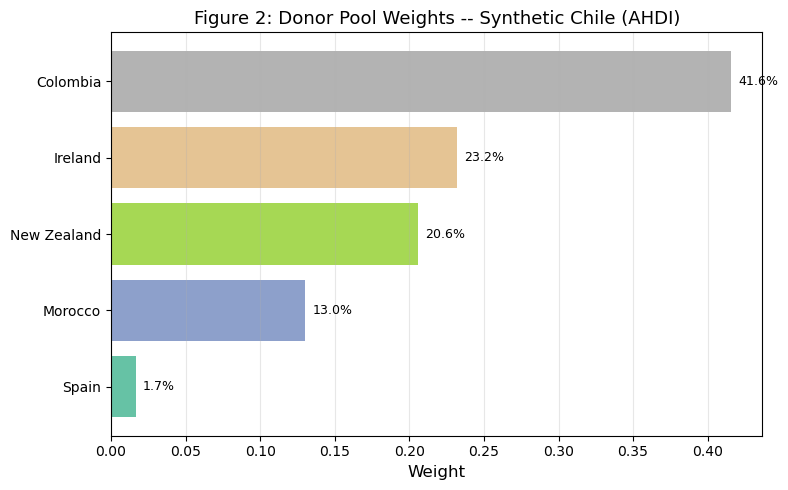

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

nonzero_w_cl = donor_weights_cl[donor_weights_cl > 0.001].sort_values()
colors_cl = plt.cm.Set2(np.linspace(0, 1, len(nonzero_w_cl)))

ax.barh(range(len(nonzero_w_cl)), nonzero_w_cl.values, color=colors_cl)
ax.set_yticks(range(len(nonzero_w_cl)))
ax.set_yticklabels(nonzero_w_cl.index, fontsize=10)
ax.set_xlabel('Weight', fontsize=12)
ax.set_title('Figure 2: Donor Pool Weights -- Synthetic Chile (AHDI)', fontsize=13)

for i, (c, w) in enumerate(nonzero_w_cl.items()):
    ax.text(w + 0.005, i, f'{w:.1%}', va='center', fontsize=9)

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Interpretation

The AHDI gap captures the aggregate welfare decline from the intervention across four
dimensions (health, education, income, and political freedom). A negative post-treatment
gap means Chile's actual AHDI fell below the synthetic counterfactual, suggesting the
coup reduced composite welfare beyond what GDP per capita alone would indicate.

Chile's raw AHDI fell from 0.358 in 1970 to 0.198 in 1975. The magnitude of
this decline and how much of it the synthetic control attributes to the coup versus
the pre-existing trajectory is the core estimate of the AHDI analysis. The gap in
the 1975-1985 window likely reflects the combination of economic disruption, elimination
of political rights, and cuts to social programs. The partial recovery after 1985
coincides with the phased relaxation of Pinochet's rule and the 1990 democratic
transition.

### Limitations

**Quinquennial data.** AHDI is measured every five years, giving only five pre-treatment
observations. This limits both the precision of the synthetic control fit and the ability
to test robustness through leave-one-out or permutation inference. Results should be
interpreted with corresponding caution.

**AHDI construction.** The political freedom component introduces measurement challenges,
as quantifying political rights involves subjective assessments that vary across sources
and methodologies. The AHDI composite may also partially reflect income effects that
overlap with the GDP per capita analysis.



---

## Brazil 1964

On April 1, 1964, the Brazilian military, with US government backing, overthrew
President Joao Goulart, ending Brazil's democratic Second Republic. General Castelo
Branco assumed the presidency and inaugurated twenty-one years of military rule
(1964-1985). The regime combined rapid industrial growth with severe political
repression, wage suppression, and widening inequality.

The AHDI analysis extends the pre-treatment window back to 1933, the earliest year for
which Brazil has AHDI data. This longer window provides more pre-treatment observations
than most case studies here and allows the synthetic control to match Brazil's welfare
trajectory through the Vargas era and the 1950s developmentalist period.

The freedom component of AHDI is particularly relevant. Brazil's regime combined
GDP growth with suppressed political rights and labor rights from 1964 onward, meaning
the AHDI and GDP gaps are expected to diverge. The AHDI analysis is designed to capture
this difference.

In [ ]:
# Brazil 1964 case study parameters
TREATED_COUNTRY_BR = "Brazil"
INTERVENTION_YEAR_BR = 1964
PRE_TREATMENT_START_BR = 1933
PRE_TREATMENT_END_BR = 1963

# AHDI is quinquennial; 5 pre-treatment and 8 post-treatment time points
AHDI_PRE_YEARS_BR  = [1933, 1938, 1950, 1955, 1960]
AHDI_POST_YEARS_BR = [1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000]
AHDI_ALL_YEARS_BR  = AHDI_PRE_YEARS_BR + AHDI_POST_YEARS_BR

# GDP screening: 25%-300% of Brazil's 1963 GDP per capita
# Wider ceiling than Chile because Brazil was a lower-income comparator
GDP_FLOOR_BR = 0.25
GDP_CEIL_BR  = 3.00

### Donor Pool Construction

The donor pool follows the same exclusion criteria as Chile. The main differences are
that Paraguay is dropped for missing AHDI data in 1933 and 1938, and Turkey is dropped
for missing PWT human capital and investment data across the pre-treatment window. The
GDP ceiling is set at 300% (versus 225% for Chile) because Brazil's 1963 income level
was lower, and a narrower ceiling would exclude too many valid comparators.

Countries that appeared in the Chile exclusion list for Chilean-specific reasons
(Uruguay's 1973 Bordaberry coup, Peru's 1968 Velasco regime) are retained here because
their confounders fall after Brazil's 1964 intervention year or do not apply.

In [ ]:
EXCLUSIONS_BR = {
    "Brazil": "Treated country",
    "Chile": "Other treated unit",
    "Dominican Republic": "Other treated unit",
    "Ecuador": "Other treated unit",
    "Argentina": "Other treated unit",
    "Cuba": "Castro socialist economy",
    "Haiti": "Duvalier dictatorship",
    "Nicaragua": "Somoza dynastic rule",
    "Guatemala": "Military government; civil war",
    "Panama": "Torrijos military; Canal Zone",
    "Bolivia": "Banzer coup 1971",
    "Bolivia (Plurinational State of)": "Banzer coup 1971",
    "Paraguay": "Stroessner; AHDI missing 1933/1938",
    "Thailand": "Military regimes",
    "Indonesia": "Suharto regime",
    "Viet Nam": "War; reunification 1975",
    "South Africa": "Apartheid",
    "Algeria": "One-party state",
    "Egypt": "Arab Socialism",
    "Syrian Arab Republic": "Ba'ath regime",
    "Syria": "Ba'ath regime",
    "Romania": "Communist",
    "Bulgaria": "Soviet satellite",
    "Hungary": "Soviet satellite",
    "Albania": "Communist",
    "Poland": "Soviet satellite",
    "Former Yugoslavia": "Socialist",
    "Yugoslavia": "Socialist",
    "Croatia": "Socialist Yugoslavia",
    "Slovenia": "Socialist Yugoslavia",
    "Bosnia and Herzegovina": "Post-Yugoslav",
    "Serbia": "Post-Yugoslav",
    "Montenegro": "Post-Yugoslav",
    "Macedonia": "Post-Yugoslav",
    "TFYR of Macedonia": "Post-Yugoslav",
    "Former USSR": "Soviet",
    "Russian Federation": "USSR",
    "Czechoslovakia": "Socialist",
    "Czech Republic": "Former Czechoslovakia",
    "Seychelles": "Socialist",
    "Congo": "Socialist 1969-1992",
    "Tunisia": "Single-party",
    "Yemen": "Socialist 1967-1990",
    "Venezuela (Bolivarian Republic of)": "OPEC; oil",
    "Venezuela": "OPEC; oil",
    "Libya": "Oil; Gaddafi",
    "Iran (Islamic Republic of)": "Oil; Revolution",
    "Iran": "Oil; Revolution",
    "Gabon": "Oil",
    "Iraq": "Oil; Ba'athist",
    "Bahrain": "Oil",
    "Saudi Arabia": "Oil",
    "Kuwait": "Oil; OPEC",
    "Trinidad and Tobago": "Oil; 1973 windfall",
    "Equatorial Guinea": "Oil",
    "Oman": "Oil",
    "Nigeria": "Oil; military coups",
    "Republic of Korea": "Asian Tiger; Park military",
    "Taiwan, Province of China": "Asian Tiger",
    "Taiwan": "Asian Tiger",
    "Malaysia": "Tiger Cub",
    "Singapore": "City-state Tiger",
    "China, Hong Kong SAR": "City-state",
    "Hong Kong": "City-state",
    "Puerto Rico": "US territory",
    "Barbados": "Small island",
    "Cyprus": "Small island; 1974 partition",
    "Mauritius": "Small island",
    "Malta": "Small island",
    "Djibouti": "French territory",
    "Saint Lucia": "Micro-economy",
    "Dominica": "Micro-island",
    "Iceland": "Micro-economy",
    "Luxembourg": "Micro-economy",
    "Lebanon": "Civil war",
    "Sri Lanka": "Tamil insurgency",
    "Liberia": "Coup 1980",
    "Namibia": "UNITA conflict",
    "Swaziland": "ANC conflicts",
    "Angola": "Colonial/civil war",
    "Cambodia": "Khmer Rouge",
    "Sudan": "Civil wars",
    "Sudan (Former)": "Civil war",
    "Palestine": "Incomplete",
    "State of Palestine": "Incomplete",
    "Jordan": "Incomplete",
    "Israel": "Yom Kippur War 1973",
    "Afghanistan": "Incomplete",
    "Benin": "Non-Atlantic",
    "Togo": "Non-Atlantic",
    "Niger": "Non-Atlantic",
    "Burkina Faso": "Non-Atlantic",
    "Mali": "Non-Atlantic",
    "Mauritania": "Non-Atlantic",
    "Gambia": "Non-Atlantic",
    "Sierra Leone": "Non-Atlantic",
    "Guinea": "Non-Atlantic",
    "Guinea-Bissau": "Non-Atlantic",
    "Côte d'Ivoire": "Non-Atlantic",
    "Cameroon": "Non-Atlantic",
    "Central African Republic": "Non-Atlantic",
    "Chad": "Non-Atlantic",
    "Uganda": "Non-Atlantic",
    "Kenya": "Non-Atlantic",
    "Tanzania": "Non-Atlantic",
    "United Republic of Tanzania": "Non-Atlantic",
    "U.R. of Tanzania: Mainland": "Non-Atlantic",
    "Zambia": "Non-Atlantic",
    "Zimbabwe": "Non-Atlantic",
    "Malawi": "Non-Atlantic",
    "Lesotho": "Non-Atlantic",
    "Rwanda": "Non-Atlantic",
    "Burundi": "Non-Atlantic",
    "Madagascar": "Non-Atlantic",
    "Ethiopia": "Non-Atlantic",
    "Somalia": "Non-Atlantic",
    "Eritrea": "Non-Atlantic",
    "Mozambique": "Non-Atlantic",
    "Ghana": "Non-Atlantic",
    "Senegal": "Non-Atlantic",
    "Botswana": "Non-Atlantic",
    "Comoros": "Non-Atlantic",
    "Democratic Republic of the Congo": "Non-Atlantic",
    "D.R. of the Congo": "Non-Atlantic",
    "Sao Tome and Principe": "Non-Atlantic",
    "Cabo Verde": "Non-Atlantic",
    "India": "Non-Atlantic",
    "Pakistan": "Non-Atlantic",
    "Nepal": "Non-Atlantic",
    "Bangladesh": "Non-Atlantic",
    "Myanmar": "Non-Atlantic",
    "Philippines": "Non-Atlantic; Marcos",
    "China": "Non-Atlantic; Maoist",
    "Mongolia": "Non-Atlantic",
    "Lao People's DR": "Non-Atlantic",
}

RETAINED_NOTES_BR = {
    "Colombia": "Democratic; key LA comparator.",
    "Costa Rica": "Democratic throughout; LA benchmark.",
    "El Salvador": "Military-dominated but no coup during Brazil pre-period. LIMITATION.",
    "Honduras": "Lopez Arellano military; retained for pool size. LIMITATION.",
    "Jamaica": "Democratic throughout; Caribbean comparator.",
    "Mexico": "PRI but market economy; key LA comparator.",
    "Peru": "Prado/Belaunde democratic 1956-1968; Velasco after Brazil's treatment start.",
    "Uruguay": "Democratic through 1973; Bordaberry coup after Brazil's treatment start.",
    "Greece": "Military junta 1967-1974. LIMITATION.",
    "Ireland": "Democratic throughout; mid-income European.",
    "Japan": "Democratic throughout; high-growth.",
    "Morocco": "Non-LA Atlantic comparator. LIMITATION.",
    "Portugal": "Caetano through 1974; Carnation Revolution. LIMITATION.",
    "Spain": "Franco through 1975; democratic transition. LIMITATION.",
    "Turkey": "Missing HC/investment data; excluded from predictor check.",
}

maddison_br = maddison_full[
    (maddison_full["year"] >= PRE_TREATMENT_START_BR) &
    (maddison_full["year"] <= 2000)
].copy()

br_gdp_1963 = maddison_br.loc[
    (maddison_br["country"] == TREATED_COUNTRY_BR) &
    (maddison_br["year"] == PRE_TREATMENT_END_BR), "gdppc"
].values[0]

gdp_screen_br = (
    maddison_br[maddison_br["year"] == PRE_TREATMENT_END_BR][['country', 'gdppc']]
    .dropna(subset=['gdppc']).copy()
)
gdp_screen_br['ratio'] = gdp_screen_br['gdppc'] / br_gdp_1963

candidates_br = gdp_screen_br[
    (gdp_screen_br['ratio'] >= GDP_FLOOR_BR) &
    (gdp_screen_br['ratio'] <= GDP_CEIL_BR) &
    (~gdp_screen_br['country'].isin(EXCLUSIONS_BR))
]['country'].tolist()

print(f"Brazil 1963 GDP: ${br_gdp_1963:,.0f}")
print(f"Candidates after GDP screening and exclusions: {len(candidates_br)}")

Brazil 1963 GDP: $3,623
Candidates after GDP screening and exclusions: 15


In [ ]:
# Keep only countries with complete AHDI and annual Maddison GDP coverage
# PWT and Barro-Lee only cover from 1950, so completeness check uses [1950,1955,1960]
maddison_required_br = set(range(1950, 2001))
final_donor_pool_br = []
dropped_br = []

for c in candidates_br:
    reasons = []

    c_ahdi = ahdi_data[
        (ahdi_data['country'] == c) & (ahdi_data['year'].isin(AHDI_ALL_YEARS_BR))
    ]
    if len(c_ahdi) < len(AHDI_ALL_YEARS_BR):
        reasons.append(f"AHDI {len(c_ahdi)}/{len(AHDI_ALL_YEARS_BR)} points")

    c_gdp = maddison_br[
        (maddison_br['country'] == c) & (maddison_br['year'].isin(maddison_required_br))
    ].dropna(subset=['gdppc'])
    if len(c_gdp) < len(maddison_required_br):
        reasons.append(f"Maddison {len(c_gdp)}/{len(maddison_required_br)} years")

    if reasons:
        dropped_br.append((c, reasons))
    else:
        final_donor_pool_br.append(c)

if dropped_br:
    print(f"Dropped for incomplete data ({len(dropped_br)}):")
    for c, reasons in dropped_br:
        print(f"  {c}: {'; '.join(reasons)}")

donor_units_br = sorted(final_donor_pool_br)
countries_of_interest_br = [TREATED_COUNTRY_BR] + donor_units_br

print(f"\nFinal donor pool: {len(donor_units_br)} countries")
for c in donor_units_br:
    gdp_val = gdp_screen_br.loc[gdp_screen_br['country'] == c, 'gdppc'].values[0]
    note = f"  ({RETAINED_NOTES_BR[c]})" if c in RETAINED_NOTES_BR else ""
    print(f"  {c}: ${gdp_val:,.0f}{note}")


Final donor pool: 15 countries
  Colombia: $4,140  (Democratic; key LA comparator.)
  Costa Rica: $4,653  (Democratic throughout; LA benchmark.)
  El Salvador: $3,096  (Military-dominated but no coup during Brazil pre-period. LIMITATION.)
  Greece: $6,122  (Military junta 1967-1974. LIMITATION.)
  Honduras: $2,177  (Lopez Arellano military; retained for pool size. LIMITATION.)
  Ireland: $7,685  (Democratic throughout; mid-income European.)
  Jamaica: $4,395  (Democratic throughout; Caribbean comparator.)
  Japan: $8,176  (Democratic throughout; high-growth.)
  Mexico: $5,118  (PRI but market economy; key LA comparator.)
  Morocco: $2,179  (Non-LA Atlantic comparator. LIMITATION.)
  Peru: $5,314  (Prado/Belaunde democratic 1956-1968; Velasco after Brazil's treatment start.)
  Portugal: $5,585  (Caetano through 1974; Carnation Revolution. LIMITATION.)
  Spain: $6,632  (Franco through 1975; democratic transition. LIMITATION.)
  Turkey: $3,374  (Missing HC/investment data; excluded from 

### Building the Analysis Panel

The Brazil panel merges the same four data sources as Chile. The pre-treatment window
extends back to 1933 for AHDI and Maddison GDP, but PWT human capital, investment, and
Barro-Lee schooling are only available from 1950. The panel therefore has full covariate
coverage at 1950, 1955, and 1960, with AHDI and GDP available at 1933 and 1938 as well.


In [ ]:
ahdi_subset_br = ahdi_data[
    (ahdi_data['country'].isin(countries_of_interest_br)) &
    (ahdi_data['year'].isin(AHDI_ALL_YEARS_BR))
].copy().rename(columns={'country': 'unit'})

madd_merge_br = maddison_br[
    (maddison_br['country'].isin(countries_of_interest_br)) &
    (maddison_br['year'].isin(AHDI_ALL_YEARS_BR))
][['country', 'year', 'gdppc']].rename(columns={'country': 'unit'})

pwt_merge_br = pwt_data[
    (pwt_data['country'].isin(countries_of_interest_br)) &
    (pwt_data['year'].isin(AHDI_ALL_YEARS_BR))
][['country', 'year', 'hc', 'csh_i']].rename(columns={'country': 'unit'})

bl_merge_br = schooling_data[
    (schooling_data['country'].isin(countries_of_interest_br)) &
    (schooling_data['year'].isin(AHDI_ALL_YEARS_BR))
][['country', 'year', 'school_years']].rename(columns={'country': 'unit'})

panel_long_br = (
    ahdi_subset_br
    .merge(madd_merge_br, on=['unit', 'year'], how='left')
    .merge(pwt_merge_br, on=['unit', 'year'], how='left')
    .merge(bl_merge_br, on=['unit', 'year'], how='left')
)

br_pre_rows = panel_long_br[
    (panel_long_br['unit'] == TREATED_COUNTRY_BR) &
    (panel_long_br['year'].isin(AHDI_PRE_YEARS_BR))
]
br_inv_mean = br_pre_rows['csh_i'].dropna().mean()
INCLUDE_INVESTMENT_BR = pd.notna(br_inv_mean) and br_inv_mean <= 0.45

print(f"Panel shape: {panel_long_br.shape}")
print(f"Columns: {list(panel_long_br.columns)}")
print(f"Brazil investment mean: {br_inv_mean:.3f} -> {'included' if INCLUDE_INVESTMENT_BR else 'excluded'}")

Panel shape: (208, 7)
Columns: ['unit', 'year', 'ahdi', 'gdppc', 'hc', 'csh_i', 'school_years']
Brazil investment mean: 0.188 -> included


### Fitting the Synthetic Control

The AHDI outcome enters `special_predictors` as two sub-period averages: 1933-1938
(early pre-treatment, available only in AHDI and Maddison) and 1950-1955-1960 (later
pre-treatment, available in all covariates). GDP per capita enters on the same schedule.
PWT and Barro-Lee covariates are built from the years at which they are non-null for
Brazil.

Because PWT and Barro-Lee begin in 1950, `has_all_preds()` uses [1950, 1955, 1960] as
the completeness-check years. Donors missing these covariates are dropped before fitting.

In [ ]:
pre_rows_br = panel_long_br[
    (panel_long_br['unit'] == TREATED_COUNTRY_BR) &
    (panel_long_br['year'].isin(AHDI_PRE_YEARS_BR))
]
hc_years_br = sorted(pre_rows_br[pre_rows_br['hc'].notna()]['year'].tolist())
bl_years_br = sorted(pre_rows_br[pre_rows_br['school_years'].notna()]['year'].tolist())
gdp_years_br = sorted(pre_rows_br[pre_rows_br['gdppc'].notna()]['year'].tolist())

# Single GDP predictor across all available pre-treatment years.
# Splitting into [1933,1938] / [1950,1955,1960] would produce NaN for donors
# that lack Maddison coverage before 1950, causing the optimizer to stall at
# equal initial weights.
special_predictors_br = [
    ('ahdi',         [1933, 1938],       'mean'),
    ('ahdi',         [1950, 1955, 1960], 'mean'),
    ('gdppc',        gdp_years_br,       'mean'),
    ('hc',           hc_years_br,        'mean'),
    ('school_years', bl_years_br,        'mean'),
]
if INCLUDE_INVESTMENT_BR:
    inv_years_br = sorted(pre_rows_br[pre_rows_br['csh_i'].notna()]['year'].tolist())
    if inv_years_br:
        special_predictors_br.append(('csh_i', inv_years_br, 'mean'))

# Drop donors only if a required predictor is completely absent across all
# pre-treatment AHDI years (all-NaN). Requiring non-null at every quinquennial
# year is too strict -- donors with partial early coverage are still usable.
required_cols_br = ['ahdi', 'gdppc', 'hc', 'school_years']
if INCLUDE_INVESTMENT_BR:
    required_cols_br.append('csh_i')
donor_units_br = [
    c for c in donor_units_br
    if not any(
        panel_long_br[
            (panel_long_br['unit'] == c) &
            (panel_long_br['year'].isin(AHDI_PRE_YEARS_BR))
        ][col].isna().all()
        for col in required_cols_br if col in panel_long_br.columns
    )
]

dataprep_br = Dataprep(
    foo=panel_long_br,
    predictors=[],
    predictors_op='mean',
    time_predictors_prior=AHDI_PRE_YEARS_BR,
    special_predictors=special_predictors_br,
    dependent='ahdi',
    unit_variable='unit',
    time_variable='year',
    treatment_identifier=TREATED_COUNTRY_BR,
    controls_identifier=donor_units_br,
    time_optimize_ssr=AHDI_PRE_YEARS_BR,
)

synth_br = Synth()
synth_br.fit(dataprep=dataprep_br, optim_method='Nelder-Mead', optim_initial='equal')

weights_raw_br = synth_br.weights(round=4)
if isinstance(weights_raw_br, pd.Series):
    w_dict_br = weights_raw_br.to_dict()
elif isinstance(weights_raw_br, pd.DataFrame):
    w_dict_br = {row.iloc[0]: float(row.iloc[1]) for _, row in weights_raw_br.iterrows()}
else:
    w_dict_br = {donor_units_br[k]: float(weights_raw_br[k]) for k in range(len(donor_units_br))}

donor_weights_br = pd.Series(w_dict_br).sort_values(ascending=False)
nonzero_br = donor_weights_br[donor_weights_br > 0.001]
print('Donor weights (nonzero):')
for c, w in nonzero_br.items():
    print(f'  {c}: {w:.4f} ({w*100:.1f}%)')
print(f'Weight sum: {donor_weights_br.sum():.4f}')

Donor weights (nonzero):
  Jamaica: 0.6390 (63.9%)
  Morocco: 0.3610 (36.1%)
Weight sum: 1.0000


### Pre-treatment Fit

The table below compares Brazil's actual AHDI to the synthetic counterpart at each
quinquennial pre-treatment time point.

In [ ]:
outcome_panel_br = panel_long_br.pivot_table(
    index='year', columns='unit', values='ahdi'
).reindex(AHDI_ALL_YEARS_BR)

actual_br = outcome_panel_br[TREATED_COUNTRY_BR].values

synth_vals_br = np.zeros(len(AHDI_ALL_YEARS_BR))
for c, w in w_dict_br.items():
    if w > 1e-6 and c in outcome_panel_br.columns:
        synth_vals_br += w * outcome_panel_br.loc[AHDI_ALL_YEARS_BR, c].values

gap_br = actual_br - synth_vals_br

pre_idx_br  = [i for i, y in enumerate(AHDI_ALL_YEARS_BR) if y in AHDI_PRE_YEARS_BR]
post_idx_br = [i for i, y in enumerate(AHDI_ALL_YEARS_BR) if y in AHDI_POST_YEARS_BR]
pre_actual_br = actual_br[pre_idx_br]
pre_synth_br  = synth_vals_br[pre_idx_br]

rmspe_pre_br = np.sqrt(np.mean((pre_actual_br - pre_synth_br) ** 2))
corr_pre_br  = np.corrcoef(pre_actual_br, pre_synth_br)[0, 1] if len(pre_actual_br) > 2 else np.nan
avg_gap_post_br = np.mean(gap_br[post_idx_br])

print(f"{'Year':>6}  {'Actual':>8}  {'Synthetic':>9}  {'Gap':>8}  {'Period':>6}")
print('-' * 50)
for i, y in enumerate(AHDI_ALL_YEARS_BR):
    period = 'PRE' if y in AHDI_PRE_YEARS_BR else 'POST'
    print(f"{y:>6}  {actual_br[i]:>8.4f}  {synth_vals_br[i]:>9.4f}  {gap_br[i]:>+8.4f}  {period:>6}")

print(f"\nPre-treatment RMSPE:       {rmspe_pre_br:.6f}")
if np.isfinite(corr_pre_br):
    print(f"Pre-treatment correlation: {corr_pre_br:.4f}")
print(f"Avg post-treatment gap:    {avg_gap_post_br:+.4f} AHDI units")

  Year    Actual  Synthetic       Gap  Period
--------------------------------------------------
  1933    0.0935     0.1090   -0.0155     PRE
  1938    0.0926     0.1206   -0.0279     PRE
  1950    0.1848     0.1551   +0.0298     PRE
  1955    0.2001     0.1902   +0.0098     PRE
  1960    0.2159     0.2222   -0.0064     PRE
  1965    0.1629     0.2502   -0.0873    POST
  1970    0.1797     0.2636   -0.0840    POST
  1975    0.1902     0.2774   -0.0872    POST
  1980    0.2343     0.2932   -0.0589    POST
  1985    0.2966     0.3114   -0.0148    POST
  1990    0.4087     0.3390   +0.0697    POST
  1995    0.4341     0.3552   +0.0789    POST
  2000    0.4556     0.3738   +0.0818    POST

Pre-treatment RMSPE:       0.020212
Pre-treatment correlation: 0.9377
Avg post-treatment gap:    -0.0127 AHDI units


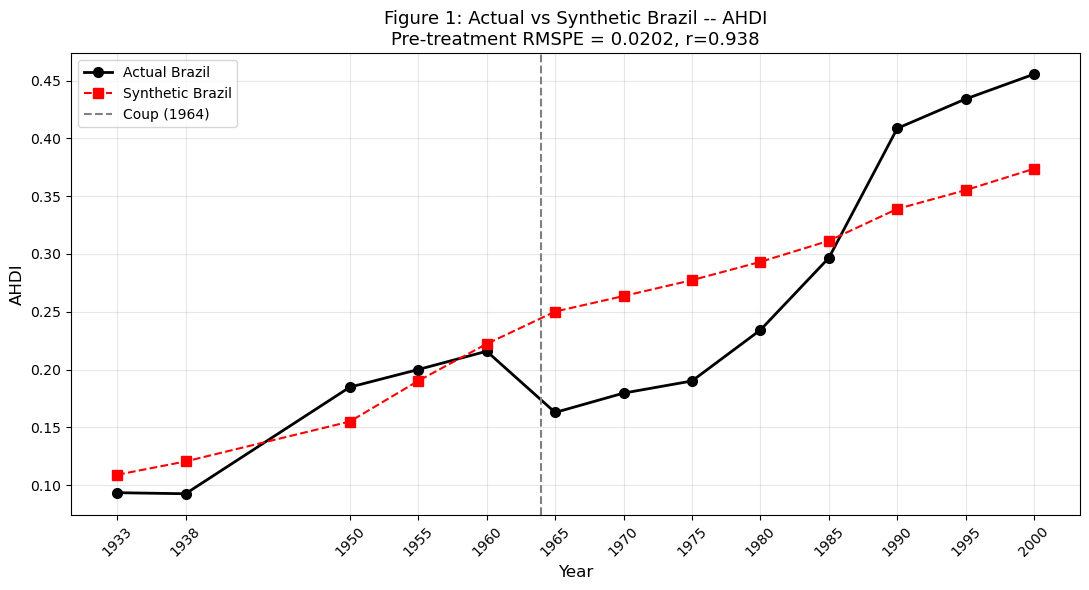

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(AHDI_ALL_YEARS_BR, actual_br, 'k-o', markersize=7, linewidth=2,
        label='Actual Brazil')
ax.plot(AHDI_ALL_YEARS_BR, synth_vals_br, 'r--s', markersize=7, linewidth=1.5,
        label='Synthetic Brazil')
ax.axvline(x=INTERVENTION_YEAR_BR, color='gray', linestyle='--',
           linewidth=1.5, label=f'Coup ({INTERVENTION_YEAR_BR})')

corr_str = f', r={corr_pre_br:.3f}' if np.isfinite(corr_pre_br) else ''
ax.set_title(
    f'Figure 1: Actual vs Synthetic Brazil -- AHDI\n'
    f'Pre-treatment RMSPE = {rmspe_pre_br:.4f}{corr_str}',
    fontsize=13
)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('AHDI', fontsize=12)
ax.set_xticks(AHDI_ALL_YEARS_BR)
ax.set_xticklabels(AHDI_ALL_YEARS_BR, rotation=45)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

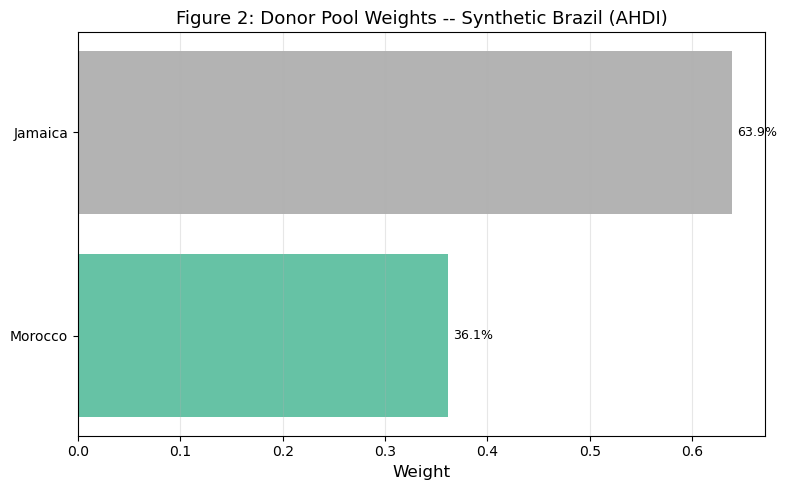

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

nonzero_w_br = donor_weights_br[donor_weights_br > 0.001].sort_values()
colors_br = plt.cm.Set2(np.linspace(0, 1, len(nonzero_w_br)))

ax.barh(range(len(nonzero_w_br)), nonzero_w_br.values, color=colors_br)
ax.set_yticks(range(len(nonzero_w_br)))
ax.set_yticklabels(nonzero_w_br.index, fontsize=10)
ax.set_xlabel('Weight', fontsize=12)
ax.set_title('Figure 2: Donor Pool Weights -- Synthetic Brazil (AHDI)', fontsize=13)

for i, (c, w) in enumerate(nonzero_w_br.items()):
    ax.text(w + 0.005, i, f'{w:.1%}', va='center', fontsize=9)

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Interpretation

Brazil's military regime combined rapid industrialization with suppressed wages and
political rights. The AHDI gap captures whether this combination produced a net welfare
loss relative to the counterfactual -- a Brazil that continued on its pre-1964
democratic trajectory.

The negative AHDI gap indicates that the political freedom and distributional
components of AHDI outweigh any income gains during the "economic miracle" period
(1968-1974).

The 1964-1985 period covers both the rapid-growth phase (1968-1974) and the debt-crisis
contraction (1981-1983). The gap is largest during the rapid-growth phase, suggesting it
is driven largely by the regime.

---

## Dominican Republic 1965

On April 24, 1965, a civil war erupted in Santo Domingo following a military-backed
revolt that sought to restore the elected government of Juan Bosch, deposed by a coup
in 1963. Three days later, US President Lyndon Johnson ordered approximately 42,000
troops into the Dominican Republic under Operation Power Pack, the largest US
military intervention in Latin America since 1928. The intervention stabilized a
conservative provisional government and led to the supervised 1966 election, which
Joaquin Balaguer, a Trujillo-era figure backed by Washington, won.

The AHDI analysis treats the 1965 compound event, coup attempt, civil war, and US
military occupation, as a single treatment. The DR had only three pre-treatment AHDI
observations (1950, 1955, 1960), which is the minimum for SCM and creates a high
overfitting risk. Results should be interpreted with caution.

The DR AHDI was rising slowly from 1950 to 1960 (from 0.094 to 0.109). The post-1965
path reflects the Balaguer-era political order, which combined economic growth with
authoritarian repression. The freedom component of AHDI is again the primary channel
through which the intervention would depress the composite index relative to a
democratic counterfactual.

In [ ]:
# Dominican Republic 1965 case study parameters
TREATED_COUNTRY_DR = "Dominican Republic"
INTERVENTION_YEAR_DR = 1965
PRE_TREATMENT_START_DR = 1950
PRE_TREATMENT_END_DR = 1964

# Only 3 pre-treatment AHDI points -- minimum viable for SCM
AHDI_PRE_YEARS_DR  = [1950, 1955, 1960]
AHDI_POST_YEARS_DR = [1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000]
AHDI_ALL_YEARS_DR  = AHDI_PRE_YEARS_DR + AHDI_POST_YEARS_DR

# GDP screening: 25%-300% of DR's 1964 GDP per capita
# Wide ceiling needed because DR was a low-income economy ($2,365)
GDP_FLOOR_DR = 0.25
GDP_CEIL_DR  = 3.00

### Donor Pool Construction

The donor pool follows the standard exclusion criteria with several DR-specific
adjustments. Advanced industrial economies (Japan, Austria, Finland, Italy, Ireland)
are excluded as structurally incomparable to a low-income Caribbean economy at
$2,365 per capita, these would easily have passed the 300% GDP ceiling. Turkey
is excluded directly here for missing PWT human capital data rather than relying on
the predictor filter downstream. Nicaragua enters the pool as a low-income Central
American market economy that was not under the same treatment.

With only 3 pre-treatment AHDI observations, the overfitting risk is significant.
The 11-country donor pool reflects the limited number of countries that have both
complete AHDI coverage back to 1950 and Maddison GDP coverage through 2000.

In [ ]:
EXCLUSIONS_DR = {
    "Dominican Republic": "Treated country",
    "Brazil": "Other treated unit",
    "Chile": "Other treated unit",
    "Ecuador": "Other treated unit",
    "Argentina": "Other treated unit",
    "Bolivia": "Barrientos coup November 1964",
    "Bolivia (Plurinational State of)": "Barrientos coup 1964",
    "Guatemala": "Military coup March 1963; civil war",
    "Thailand": "Military regimes; coup 1964",
    "Viet Nam": "Multiple coups 1963-1964",
    "Indonesia": "Suharto coup 1965",
    "Cuba": "Castro socialist economy",
    "Haiti": "Duvalier dictatorship",
    "Paraguay": "Stroessner dictatorship",
    "Panama": "US Canal Zone; Torrijos military 1968",
    "Japan": "Advanced industrial; structurally incomparable to DR at $2,365",
    "Austria": "Advanced industrial; structurally incomparable",
    "Finland": "Nordic welfare state; incomparable",
    "Italy": "G7 advanced economy; incomparable",
    "Ireland": "Advanced economy; incomparable",
    "Turkey": "Missing PWT HC data pre-1964",
    "Venezuela (Bolivarian Republic of)": "OPEC; oil",
    "Venezuela": "OPEC; oil",
    "Libya": "Oil; Gaddafi",
    "Iran (Islamic Republic of)": "Oil",
    "Iran": "Oil",
    "Gabon": "Oil",
    "Iraq": "Oil; Ba'athist",
    "Bahrain": "Oil",
    "Saudi Arabia": "Oil",
    "Kuwait": "Oil; OPEC",
    "Trinidad and Tobago": "Oil; 1973 windfall",
    "Equatorial Guinea": "Oil",
    "Oman": "Oil",
    "Nigeria": "Oil; Biafra 1967-1970",
    "Republic of Korea": "Asian Tiger; Park military",
    "Taiwan, Province of China": "Asian Tiger",
    "Taiwan": "Asian Tiger",
    "Malaysia": "Tiger Cub",
    "Singapore": "City-state Tiger",
    "China, Hong Kong SAR": "City-state",
    "Hong Kong": "City-state",
    "Puerto Rico": "US territory",
    "Barbados": "Small island",
    "Cyprus": "Small island; 1974 partition",
    "Mauritius": "Small island",
    "Malta": "Small island",
    "Jamaica": "Small island; Manley socialism 1972-1980",
    "Djibouti": "French territory",
    "Saint Lucia": "Micro-economy",
    "Dominica": "Micro-island",
    "Iceland": "Micro-economy",
    "Luxembourg": "Micro-economy",
    "South Africa": "Apartheid",
    "Algeria": "One-party state",
    "Egypt": "Arab Socialism",
    "Syrian Arab Republic": "Ba'ath regime",
    "Syria": "Ba'ath regime",
    "Romania": "Communist",
    "Bulgaria": "Soviet satellite",
    "Hungary": "Soviet satellite",
    "Albania": "Communist",
    "Poland": "Soviet satellite",
    "Former Yugoslavia": "Socialist",
    "Yugoslavia": "Socialist",
    "Croatia": "Socialist Yugoslavia",
    "Slovenia": "Socialist Yugoslavia",
    "Bosnia and Herzegovina": "Post-Yugoslav",
    "Serbia": "Post-Yugoslav",
    "Montenegro": "Post-Yugoslav",
    "Macedonia": "Post-Yugoslav",
    "TFYR of Macedonia": "Post-Yugoslav",
    "Former USSR": "Soviet",
    "Russian Federation": "USSR",
    "Czechoslovakia": "Socialist",
    "Czech Republic": "Former Czechoslovakia",
    "Seychelles": "Socialist",
    "Congo": "Socialist 1969-1992",
    "Tunisia": "Single-party",
    "Yemen": "Socialist 1967-1990",
    "Lebanon": "Civil war",
    "Sri Lanka": "Tamil insurgency",
    "Liberia": "Coup 1980",
    "Namibia": "UNITA conflict",
    "Swaziland": "ANC conflicts",
    "Angola": "Colonial/civil war",
    "Cambodia": "Khmer Rouge",
    "Sudan": "Civil wars",
    "Sudan (Former)": "Civil war",
    "Palestine": "Incomplete",
    "State of Palestine": "Incomplete",
    "Jordan": "Incomplete",
    "Israel": "Military spending distortion",
    "Afghanistan": "Incomplete",
    "Benin": "Non-Atlantic",
    "Togo": "Non-Atlantic",
    "Niger": "Non-Atlantic",
    "Burkina Faso": "Non-Atlantic",
    "Mali": "Non-Atlantic",
    "Mauritania": "Non-Atlantic",
    "Gambia": "Non-Atlantic",
    "Sierra Leone": "Non-Atlantic",
    "Guinea": "Non-Atlantic",
    "Guinea-Bissau": "Non-Atlantic",
    "Côte d'Ivoire": "Non-Atlantic",
    "Cameroon": "Non-Atlantic",
    "Central African Republic": "Non-Atlantic",
    "Chad": "Non-Atlantic",
    "Uganda": "Non-Atlantic",
    "Kenya": "Non-Atlantic",
    "Tanzania": "Non-Atlantic",
    "United Republic of Tanzania": "Non-Atlantic",
    "U.R. of Tanzania: Mainland": "Non-Atlantic",
    "Zambia": "Non-Atlantic",
    "Zimbabwe": "Non-Atlantic",
    "Malawi": "Non-Atlantic",
    "Lesotho": "Non-Atlantic",
    "Rwanda": "Non-Atlantic",
    "Burundi": "Non-Atlantic",
    "Madagascar": "Non-Atlantic",
    "Ethiopia": "Non-Atlantic",
    "Somalia": "Non-Atlantic",
    "Eritrea": "Non-Atlantic",
    "Mozambique": "Non-Atlantic",
    "Ghana": "Non-Atlantic",
    "Senegal": "Non-Atlantic",
    "Botswana": "Non-Atlantic",
    "Comoros": "Non-Atlantic",
    "Democratic Republic of the Congo": "Non-Atlantic",
    "D.R. of the Congo": "Non-Atlantic",
    "Sao Tome and Principe": "Non-Atlantic",
    "Cabo Verde": "Non-Atlantic",
    "India": "Non-Atlantic",
    "Pakistan": "Non-Atlantic",
    "Nepal": "Non-Atlantic",
    "Bangladesh": "Non-Atlantic",
    "Myanmar": "Non-Atlantic",
    "Philippines": "Non-Atlantic; Marcos",
    "China": "Non-Atlantic; Maoist",
    "Mongolia": "Non-Atlantic",
    "Lao People's DR": "Non-Atlantic",
}

RETAINED_NOTES_DR = {
    "Colombia": "Democratic through period; key LA comparator.",
    "Costa Rica": "Democratic throughout; LA benchmark.",
    "El Salvador": "Military governance but market economy. LIMITATION.",
    "Greece": "Military junta 1967-1974. LIMITATION.",
    "Honduras": "Lopez Arellano coup Oct 1963; closest income match below DR. LIMITATION.",
    "Mexico": "PRI but market economy; key LA comparator.",
    "Morocco": "Non-LA Atlantic comparator. LIMITATION.",
    "Nicaragua": "Somoza-era but market economy; low-income LA donor. LIMITATION.",
    "Peru": "Democratic through 1968; Andean market economy.",
    "Portugal": "Caetano through 1974; Carnation Revolution. LIMITATION.",
    "Spain": "Franco through 1975; democratic transition. LIMITATION.",
}

maddison_dr = maddison_full[
    (maddison_full["year"] >= PRE_TREATMENT_START_DR) &
    (maddison_full["year"] <= 2000)
].copy()

dr_gdp_1964 = maddison_dr.loc[
    (maddison_dr["country"] == TREATED_COUNTRY_DR) &
    (maddison_dr["year"] == PRE_TREATMENT_END_DR), "gdppc"
].values[0]

gdp_screen_dr = (
    maddison_dr[maddison_dr["year"] == PRE_TREATMENT_END_DR][['country', 'gdppc']]
    .dropna(subset=['gdppc']).copy()
)
gdp_screen_dr['ratio'] = gdp_screen_dr['gdppc'] / dr_gdp_1964

candidates_dr = gdp_screen_dr[
    (gdp_screen_dr['ratio'] >= GDP_FLOOR_DR) &
    (gdp_screen_dr['ratio'] <= GDP_CEIL_DR) &
    (~gdp_screen_dr['country'].isin(EXCLUSIONS_DR))
]['country'].tolist()

print(f"Dominican Republic 1964 GDP: ${dr_gdp_1964:,.0f}")
print(f"Candidates after GDP screening and exclusions: {len(candidates_dr)}")

Dominican Republic 1964 GDP: $2,365
Candidates after GDP screening and exclusions: 11


In [ ]:
maddison_required_dr = set(range(1950, 2001))
final_donor_pool_dr = []
dropped_dr = []

for c in candidates_dr:
    reasons = []

    c_ahdi = ahdi_data[
        (ahdi_data['country'] == c) & (ahdi_data['year'].isin(AHDI_ALL_YEARS_DR))
    ]
    if len(c_ahdi) < len(AHDI_ALL_YEARS_DR):
        reasons.append(f"AHDI {len(c_ahdi)}/{len(AHDI_ALL_YEARS_DR)} points")

    c_gdp = maddison_dr[
        (maddison_dr['country'] == c) & (maddison_dr['year'].isin(maddison_required_dr))
    ].dropna(subset=['gdppc'])
    if len(c_gdp) < len(maddison_required_dr):
        reasons.append(f"Maddison {len(c_gdp)}/{len(maddison_required_dr)} years")

    if reasons:
        dropped_dr.append((c, reasons))
    else:
        final_donor_pool_dr.append(c)

if dropped_dr:
    print(f"Dropped for incomplete data ({len(dropped_dr)}):")
    for c, reasons in dropped_dr:
        print(f"  {c}: {'; '.join(reasons)}")

donor_units_dr = sorted(final_donor_pool_dr)
countries_of_interest_dr = [TREATED_COUNTRY_DR] + donor_units_dr

print(f"\nFinal donor pool: {len(donor_units_dr)} countries")
for c in donor_units_dr:
    gdp_val = gdp_screen_dr.loc[gdp_screen_dr['country'] == c, 'gdppc'].values[0]
    note = f"  ({RETAINED_NOTES_DR[c]})" if c in RETAINED_NOTES_DR else ""
    print(f"  {c}: ${gdp_val:,.0f}{note}")


Final donor pool: 11 countries
  Colombia: $4,264  (Democratic through period; key LA comparator.)
  Costa Rica: $4,720  (Democratic throughout; LA benchmark.)
  El Salvador: $3,282  (Military governance but market economy. LIMITATION.)
  Greece: $6,601  (Military junta 1967-1974. LIMITATION.)
  Honduras: $2,209  (Lopez Arellano coup Oct 1963; closest income match below DR. LIMITATION.)
  Mexico: $5,555  (PRI but market economy; key LA comparator.)
  Morocco: $2,201  (Non-LA Atlantic comparator. LIMITATION.)
  Nicaragua: $4,092  (Somoza-era but market economy; low-income LA donor. LIMITATION.)
  Peru: $5,523  (Democratic through 1968; Andean market economy.)
  Portugal: $5,926  (Caetano through 1974; Carnation Revolution. LIMITATION.)
  Spain: $6,938  (Franco through 1975; democratic transition. LIMITATION.)


### Building the Analysis Panel

The DR panel is built identically to the other case studies, but covers only the
quinquennial years from 1950 onward. With 3 pre-treatment and 8 post-treatment time
points (11 total), the panel is considerably shorter than Brazil's.

In [ ]:
ahdi_subset_dr = ahdi_data[
    (ahdi_data['country'].isin(countries_of_interest_dr)) &
    (ahdi_data['year'].isin(AHDI_ALL_YEARS_DR))
].copy().rename(columns={'country': 'unit'})

madd_merge_dr = maddison_dr[
    (maddison_dr['country'].isin(countries_of_interest_dr)) &
    (maddison_dr['year'].isin(AHDI_ALL_YEARS_DR))
][['country', 'year', 'gdppc']].rename(columns={'country': 'unit'})

pwt_merge_dr = pwt_data[
    (pwt_data['country'].isin(countries_of_interest_dr)) &
    (pwt_data['year'].isin(AHDI_ALL_YEARS_DR))
][['country', 'year', 'hc', 'csh_i']].rename(columns={'country': 'unit'})

bl_merge_dr = schooling_data[
    (schooling_data['country'].isin(countries_of_interest_dr)) &
    (schooling_data['year'].isin(AHDI_ALL_YEARS_DR))
][['country', 'year', 'school_years']].rename(columns={'country': 'unit'})

panel_long_dr = (
    ahdi_subset_dr
    .merge(madd_merge_dr, on=['unit', 'year'], how='left')
    .merge(pwt_merge_dr, on=['unit', 'year'], how='left')
    .merge(bl_merge_dr, on=['unit', 'year'], how='left')
)

dr_pre_rows = panel_long_dr[
    (panel_long_dr['unit'] == TREATED_COUNTRY_DR) &
    (panel_long_dr['year'].isin(AHDI_PRE_YEARS_DR))
]
dr_inv_mean = dr_pre_rows['csh_i'].dropna().mean()
INCLUDE_INVESTMENT_DR = pd.notna(dr_inv_mean) and dr_inv_mean <= 0.45

print(f"Panel shape: {panel_long_dr.shape}")
print(f"Columns: {list(panel_long_dr.columns)}")
print(f"DR investment mean: {dr_inv_mean:.3f} -> {'included' if INCLUDE_INVESTMENT_DR else 'excluded'}")

Panel shape: (132, 7)
Columns: ['unit', 'year', 'ahdi', 'gdppc', 'hc', 'csh_i', 'school_years']
DR investment mean: 0.108 -> included


### Fitting the Synthetic Control

With only 3 pre-treatment time points, the AHDI predictor enters as three
individual year entries rather than sub-period averages. This gives the optimizer
maximum leverage on the level-matching problem given the limited pre-treatment
window. The overfitting risk is significant with 11 donors and 3 time points. Thus,
near-perfect pre-treatment fit is expected but does not validate the counterfactual.

The predictors (GDP, HC, schooling, investment) provide some balance across the pre-treatment
window as a partial guard against pure level-fitting.

In [ ]:
pre_rows_dr = panel_long_dr[
    (panel_long_dr['unit'] == TREATED_COUNTRY_DR) &
    (panel_long_dr['year'].isin(AHDI_PRE_YEARS_DR))
]
hc_years_dr = sorted(pre_rows_dr[pre_rows_dr['hc'].notna()]['year'].tolist())
bl_years_dr = sorted(pre_rows_dr[pre_rows_dr['school_years'].notna()]['year'].tolist())
gdp_years_dr = sorted(pre_rows_dr[pre_rows_dr['gdppc'].notna()]['year'].tolist())

# With only 3 pre-treatment years, each AHDI point enters as its own predictor
# instead of sub-period averages used in cases with more observations.
special_predictors_dr = [
    ('ahdi',         [1950], 'mean'),
    ('ahdi',         [1955], 'mean'),
    ('ahdi',         [1960], 'mean'),
    ('gdppc',        gdp_years_dr, 'mean'),
    ('hc',           hc_years_dr,  'mean'),
    ('school_years', bl_years_dr,  'mean'),
]
if INCLUDE_INVESTMENT_DR:
    inv_years_dr = sorted(pre_rows_dr[pre_rows_dr['csh_i'].notna()]['year'].tolist())
    if inv_years_dr:
        special_predictors_dr.append(('csh_i', inv_years_dr, 'mean'))

# Drop donors only if a required predictor is completely absent
required_cols_dr = ['ahdi', 'gdppc', 'hc', 'school_years']
if INCLUDE_INVESTMENT_DR:
    required_cols_dr.append('csh_i')
donor_units_dr = [
    c for c in donor_units_dr
    if not any(
        panel_long_dr[
            (panel_long_dr['unit'] == c) &
            (panel_long_dr['year'].isin(AHDI_PRE_YEARS_DR))
        ][col].isna().all()
        for col in required_cols_dr if col in panel_long_dr.columns
    )
]

dataprep_dr = Dataprep(
    foo=panel_long_dr,
    predictors=[],
    predictors_op='mean',
    time_predictors_prior=AHDI_PRE_YEARS_DR,
    special_predictors=special_predictors_dr,
    dependent='ahdi',
    unit_variable='unit',
    time_variable='year',
    treatment_identifier=TREATED_COUNTRY_DR,
    controls_identifier=donor_units_dr,
    time_optimize_ssr=AHDI_PRE_YEARS_DR,
)

synth_dr = Synth()
synth_dr.fit(dataprep=dataprep_dr, optim_method='Nelder-Mead', optim_initial='equal')

weights_raw_dr = synth_dr.weights(round=4)
if isinstance(weights_raw_dr, pd.Series):
    w_dict_dr = weights_raw_dr.to_dict()
elif isinstance(weights_raw_dr, pd.DataFrame):
    w_dict_dr = {row.iloc[0]: float(row.iloc[1]) for _, row in weights_raw_dr.iterrows()}
else:
    w_dict_dr = {donor_units_dr[k]: float(weights_raw_dr[k]) for k in range(len(donor_units_dr))}

donor_weights_dr = pd.Series(w_dict_dr).sort_values(ascending=False)
nonzero_dr = donor_weights_dr[donor_weights_dr > 0.001]
print('Donor weights (nonzero):')
for c, w in nonzero_dr.items():
    print(f'  {c}: {w:.4f} ({w*100:.1f}%)')
print(f'Weight sum: {donor_weights_dr.sum():.4f}')

Donor weights (nonzero):
  El Salvador: 0.3173 (31.7%)
  Morocco: 0.2931 (29.3%)
  Nicaragua: 0.2271 (22.7%)
  Honduras: 0.1624 (16.2%)
Weight sum: 0.9999


### Pre-treatment Fit

A near-perfect fit is a known artifact of the low pre-treatment
observation count relative to the donor pool size.

In [ ]:
outcome_panel_dr = panel_long_dr.pivot_table(
    index='year', columns='unit', values='ahdi'
).reindex(AHDI_ALL_YEARS_DR)

actual_dr = outcome_panel_dr[TREATED_COUNTRY_DR].values

synth_vals_dr = np.zeros(len(AHDI_ALL_YEARS_DR))
for c, w in w_dict_dr.items():
    if w > 1e-6 and c in outcome_panel_dr.columns:
        synth_vals_dr += w * outcome_panel_dr.loc[AHDI_ALL_YEARS_DR, c].values

gap_dr = actual_dr - synth_vals_dr

pre_idx_dr  = [i for i, y in enumerate(AHDI_ALL_YEARS_DR) if y in AHDI_PRE_YEARS_DR]
post_idx_dr = [i for i, y in enumerate(AHDI_ALL_YEARS_DR) if y in AHDI_POST_YEARS_DR]
pre_actual_dr = actual_dr[pre_idx_dr]
pre_synth_dr  = synth_vals_dr[pre_idx_dr]

rmspe_pre_dr = np.sqrt(np.mean((pre_actual_dr - pre_synth_dr) ** 2))
corr_pre_dr  = np.corrcoef(pre_actual_dr, pre_synth_dr)[0, 1] if len(pre_actual_dr) > 2 else np.nan
avg_gap_post_dr = np.mean(gap_dr[post_idx_dr])

print(f"{'Year':>6}  {'Actual':>8}  {'Synthetic':>9}  {'Gap':>8}  {'Period':>6}")
print('-' * 50)
for i, y in enumerate(AHDI_ALL_YEARS_DR):
    period = 'PRE' if y in AHDI_PRE_YEARS_DR else 'POST'
    print(f"{y:>6}  {actual_dr[i]:>8.4f}  {synth_vals_dr[i]:>9.4f}  {gap_dr[i]:>+8.4f}  {period:>6}")

print(f"\nPre-treatment RMSPE:       {rmspe_pre_dr:.6f}")
if np.isfinite(corr_pre_dr):
    print(f"Pre-treatment correlation: {corr_pre_dr:.4f}")
print(f"Avg post-treatment gap:    {avg_gap_post_dr:+.4f} AHDI units")

  Year    Actual  Synthetic       Gap  Period
--------------------------------------------------
  1950    0.0936     0.0940   -0.0004     PRE
  1955    0.1025     0.1011   +0.0014     PRE
  1960    0.1089     0.1113   -0.0023     PRE
  1965    0.1539     0.1259   +0.0280    POST
  1970    0.1702     0.1341   +0.0361    POST
  1975    0.1822     0.1405   +0.0417    POST
  1980    0.2604     0.1622   +0.0982    POST
  1985    0.2769     0.2001   +0.0768    POST
  1990    0.2787     0.2323   +0.0464    POST
  1995    0.2897     0.2770   +0.0127    POST
  2000    0.3389     0.2968   +0.0421    POST

Pre-treatment RMSPE:       0.001591
Pre-treatment correlation: 0.9811
Avg post-treatment gap:    +0.0477 AHDI units


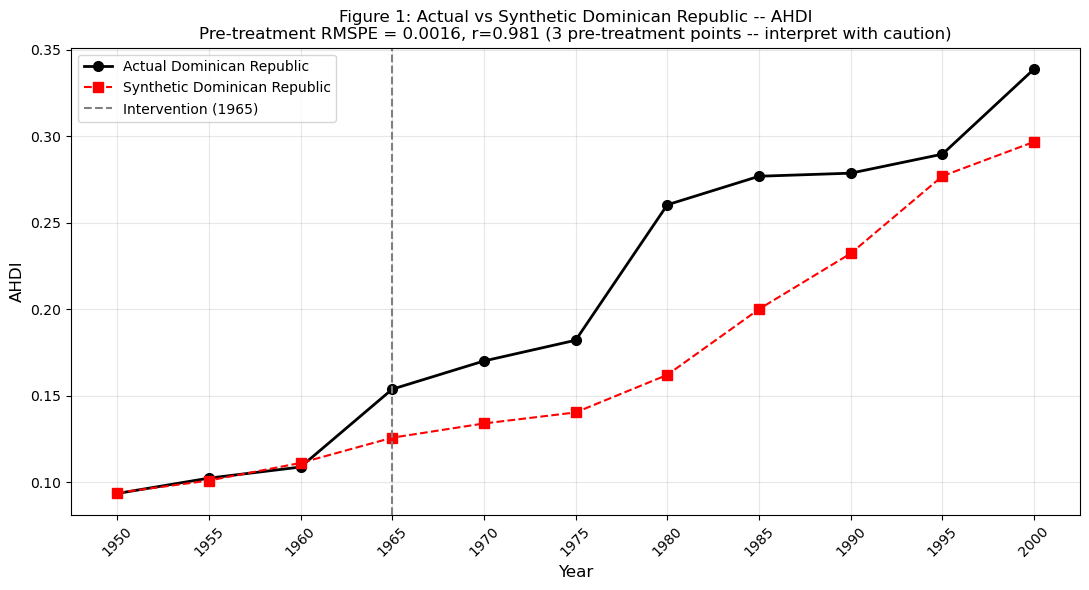

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(AHDI_ALL_YEARS_DR, actual_dr, 'k-o', markersize=7, linewidth=2,
        label='Actual Dominican Republic')
ax.plot(AHDI_ALL_YEARS_DR, synth_vals_dr, 'r--s', markersize=7, linewidth=1.5,
        label='Synthetic Dominican Republic')
ax.axvline(x=INTERVENTION_YEAR_DR, color='gray', linestyle='--',
           linewidth=1.5, label=f'Intervention ({INTERVENTION_YEAR_DR})')

corr_str = f', r={corr_pre_dr:.3f}' if np.isfinite(corr_pre_dr) else ''
ax.set_title(
    f'Figure 1: Actual vs Synthetic Dominican Republic -- AHDI\n'
    f'Pre-treatment RMSPE = {rmspe_pre_dr:.4f}{corr_str} '
    f'(3 pre-treatment points -- interpret with caution)',
    fontsize=12
)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('AHDI', fontsize=12)
ax.set_xticks(AHDI_ALL_YEARS_DR)
ax.set_xticklabels(AHDI_ALL_YEARS_DR, rotation=45)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

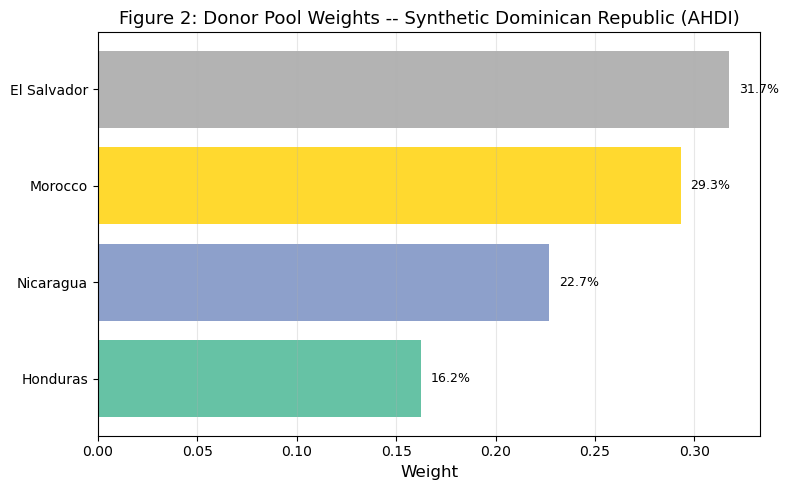

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

nonzero_w_dr = donor_weights_dr[donor_weights_dr > 0.001].sort_values()
colors_dr = plt.cm.Set2(np.linspace(0, 1, len(nonzero_w_dr)))

ax.barh(range(len(nonzero_w_dr)), nonzero_w_dr.values, color=colors_dr)
ax.set_yticks(range(len(nonzero_w_dr)))
ax.set_yticklabels(nonzero_w_dr.index, fontsize=10)
ax.set_xlabel('Weight', fontsize=12)
ax.set_title('Figure 2: Donor Pool Weights -- Synthetic Dominican Republic (AHDI)', fontsize=13)

for i, (c, w) in enumerate(nonzero_w_dr.items()):
    ax.text(w + 0.005, i, f'{w:.1%}', va='center', fontsize=9)

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Interpretation

The Dominican Republic case is distinct from Chile and Brazil because the
1965 treatment combines a domestic coup attempt and a direct US military occupation.
The AHDI analysis cannot separate the effects of these two components.

The post-1965 AHDI trajectory under Balaguer (1966-1978) reflected economic growth
financed partly by sugar exports and US aid, alongside political repression and
curtailed civil liberties. The freedom component of AHDI would be expected to register
a sustained negative gap relative to the counterfactual.

A positive AHDI gap (actual above synthetic) would suggest that growth and social
investment outweighed the freedom penalty in the composite index. The negative gap
indicates the opposite. Given the DR's position as one of the lowest-income countries
in the donor pool, even small absolute AHDI changes carry substantial implications.

### Limitations

**Three pre-treatment observations.** With only 1950, 1955, and 1960 as pre-treatment
AHDI points, the synthetic control has minimal trajectory information. Near-perfect
pre-treatment fit is expected by construction and is not evidence of a valid
counterfactual. The RMSPE and correlation from three points are not meaningful
goodness-of-fit statistics.

**Compound treatment.** The 1965 event includes both a domestic political crisis and
a US military intervention with 42,000 troops. The SCM estimates the combined effect
of these concurrent treatments. The counterfactual is a Dominican Republic that
experienced neither, which is a more complex hypothetical than a no-coup
scenario.

**Freedom component measurement.** Political freedom quantification before 1970 is
particularly uncertain. The AHDI freedom component for the 1950-1965 period relies on
earlier cross-national surveys with less reliable coverage than post-1970 measures.

---

## Ecuador 1963

On July 11, 1963, a military junta led by Captain Ramon Castro Jijon overthrew
President Carlos Julio Arosemena, who had been elected in 1961 and was seen by
Washington as insufficiently anti-communist. The coup ended a decade of unstable
constitutional governance and inaugurated three years of direct military rule before
a return to civilian government in 1966.

Ecuador had only three pre-treatment AHDI observations (1950, 1955, 1960), the same
minimum as the Dominican Republic. The overfitting risk is identical: with 11 donors
and 3 matching points, near-perfect pre-treatment fit is achievable by construction
and does not validate the counterfactual.

Ecuador's 1960 AHDI was 0.210, rising steadily from 0.184 in 1950. The post-1963
trajectory shows a dip to 0.170 in 1965 before recovering through the 1970s and
accelerating in the 1980s, partly driven by oil revenues following the 1972 discovery
of significant Amazon reserves.

In [ ]:
# Ecuador 1963 case study parameters
TREATED_COUNTRY_EC = "Ecuador"
INTERVENTION_YEAR_EC = 1963
PRE_TREATMENT_START_EC = 1950
PRE_TREATMENT_END_EC = 1962

# Only 3 pre-treatment AHDI points -- minimum viable for SCM
AHDI_PRE_YEARS_EC  = [1950, 1955, 1960]
AHDI_POST_YEARS_EC = [1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000]
AHDI_ALL_YEARS_EC  = AHDI_PRE_YEARS_EC + AHDI_POST_YEARS_EC

# GDP screening: 25%-300% of Ecuador's 1962 GDP per capita
GDP_FLOOR_EC = 0.25
GDP_CEIL_EC  = 3.00

### Donor Pool Construction

Ecuador's exclusion list differs from the DR in two notable ways. First, the DR is
now excluded as another treated unit (1965). Second, Uruguay is excluded because of
the Bordaberry coup in 1973, which falls within Ecuador's post-treatment window.

Ecuador's PWT investment share is approximately 60%, which is implausible as a
structural predictor and reflects a known PWT data anomaly for Ecuador in this period.
Investment is excluded from the predictor set for this case study.

In [ ]:
EXCLUSIONS_EC = {
    "Ecuador": "Treated country",
    "Brazil": "Other treated unit",
    "Chile": "Other treated unit",
    "Dominican Republic": "Other treated unit",
    "Argentina": "Other treated unit",
    "Guatemala": "Military coup March 1963; contemporaneous",
    "Bolivia": "Barrientos coup November 1964",
    "Bolivia (Plurinational State of)": "Barrientos coup 1964",
    "Uruguay": "Bordaberry coup 1973; falls within post-treatment window",
    "Cuba": "Castro socialist economy",
    "Haiti": "Duvalier dictatorship",
    "Paraguay": "Stroessner dictatorship",
    "Panama": "US Canal Zone; Torrijos military 1968",
    "Japan": "Advanced industrial; structurally incomparable to Ecuador at $3,716",
    "Austria": "Advanced industrial; structurally incomparable",
    "Finland": "Nordic welfare state; incomparable",
    "Italy": "G7 advanced economy; incomparable",
    "Ireland": "Advanced economy; incomparable",
    "Turkey": "Missing PWT HC data pre-1963",
    "Viet Nam": "Multiple coups 1963-1964",
    "Thailand": "Military regimes; coup 1964",
    "Indonesia": "Suharto coup 1965",
    "Venezuela (Bolivarian Republic of)": "OPEC; oil",
    "Venezuela": "OPEC; oil",
    "Libya": "Oil; Gaddafi",
    "Iran (Islamic Republic of)": "Oil",
    "Iran": "Oil",
    "Gabon": "Oil",
    "Iraq": "Oil; Ba'athist",
    "Bahrain": "Oil",
    "Saudi Arabia": "Oil",
    "Kuwait": "Oil; OPEC",
    "Trinidad and Tobago": "Oil; 1973 windfall",
    "Equatorial Guinea": "Oil",
    "Oman": "Oil",
    "Nigeria": "Oil; Biafra 1967-1970",
    "Republic of Korea": "Asian Tiger; Park military",
    "Taiwan, Province of China": "Asian Tiger",
    "Taiwan": "Asian Tiger",
    "Malaysia": "Tiger Cub",
    "Singapore": "City-state Tiger",
    "China, Hong Kong SAR": "City-state",
    "Hong Kong": "City-state",
    "Puerto Rico": "US territory",
    "Barbados": "Small island",
    "Cyprus": "Small island; 1974 partition",
    "Mauritius": "Small island",
    "Malta": "Small island",
    "Jamaica": "Small island",
    "Djibouti": "French territory",
    "Saint Lucia": "Micro-economy",
    "Dominica": "Micro-island",
    "Iceland": "Micro-economy",
    "Luxembourg": "Micro-economy",
    "South Africa": "Apartheid",
    "Algeria": "One-party state",
    "Egypt": "Arab Socialism",
    "Syrian Arab Republic": "Ba'ath regime",
    "Syria": "Ba'ath regime",
    "Romania": "Communist",
    "Bulgaria": "Soviet satellite",
    "Hungary": "Soviet satellite",
    "Albania": "Communist",
    "Poland": "Soviet satellite",
    "Former Yugoslavia": "Socialist",
    "Yugoslavia": "Socialist",
    "Croatia": "Socialist Yugoslavia",
    "Slovenia": "Socialist Yugoslavia",
    "Bosnia and Herzegovina": "Post-Yugoslav",
    "Serbia": "Post-Yugoslav",
    "Montenegro": "Post-Yugoslav",
    "Macedonia": "Post-Yugoslav",
    "TFYR of Macedonia": "Post-Yugoslav",
    "Former USSR": "Soviet",
    "Russian Federation": "USSR",
    "Czechoslovakia": "Socialist",
    "Czech Republic": "Former Czechoslovakia",
    "Seychelles": "Socialist",
    "Congo": "Socialist 1969-1992",
    "Tunisia": "Single-party",
    "Yemen": "Socialist 1967-1990",
    "Lebanon": "Civil war",
    "Sri Lanka": "Tamil insurgency",
    "Liberia": "Coup 1980",
    "Namibia": "UNITA conflict",
    "Swaziland": "ANC conflicts",
    "Angola": "Colonial/civil war",
    "Cambodia": "Khmer Rouge",
    "Sudan": "Civil wars",
    "Sudan (Former)": "Civil war",
    "Palestine": "Incomplete",
    "State of Palestine": "Incomplete",
    "Jordan": "Incomplete",
    "Israel": "Military spending distortion",
    "Afghanistan": "Incomplete",
    "Benin": "Non-Atlantic",
    "Togo": "Non-Atlantic",
    "Niger": "Non-Atlantic",
    "Burkina Faso": "Non-Atlantic",
    "Mali": "Non-Atlantic",
    "Mauritania": "Non-Atlantic",
    "Gambia": "Non-Atlantic",
    "Sierra Leone": "Non-Atlantic",
    "Guinea": "Non-Atlantic",
    "Guinea-Bissau": "Non-Atlantic",
    "Côte d'Ivoire": "Non-Atlantic",
    "Cameroon": "Non-Atlantic",
    "Central African Republic": "Non-Atlantic",
    "Chad": "Non-Atlantic",
    "Uganda": "Non-Atlantic",
    "Kenya": "Non-Atlantic",
    "Tanzania": "Non-Atlantic",
    "United Republic of Tanzania": "Non-Atlantic",
    "U.R. of Tanzania: Mainland": "Non-Atlantic",
    "Zambia": "Non-Atlantic",
    "Zimbabwe": "Non-Atlantic",
    "Malawi": "Non-Atlantic",
    "Lesotho": "Non-Atlantic",
    "Rwanda": "Non-Atlantic",
    "Burundi": "Non-Atlantic",
    "Madagascar": "Non-Atlantic",
    "Ethiopia": "Non-Atlantic",
    "Somalia": "Non-Atlantic",
    "Eritrea": "Non-Atlantic",
    "Mozambique": "Non-Atlantic",
    "Ghana": "Non-Atlantic",
    "Senegal": "Non-Atlantic",
    "Botswana": "Non-Atlantic",
    "Comoros": "Non-Atlantic",
    "Democratic Republic of the Congo": "Non-Atlantic",
    "D.R. of the Congo": "Non-Atlantic",
    "Sao Tome and Principe": "Non-Atlantic",
    "Cabo Verde": "Non-Atlantic",
    "India": "Non-Atlantic",
    "Pakistan": "Non-Atlantic",
    "Nepal": "Non-Atlantic",
    "Bangladesh": "Non-Atlantic",
    "Myanmar": "Non-Atlantic",
    "Philippines": "Non-Atlantic; Marcos",
    "China": "Non-Atlantic; Maoist",
    "Mongolia": "Non-Atlantic",
    "Lao People's DR": "Non-Atlantic",
}

RETAINED_NOTES_EC = {
    "Colombia": "Democratic through period; key LA comparator.",
    "Costa Rica": "Democratic throughout; LA benchmark.",
    "El Salvador": "Military governance but market economy. LIMITATION.",
    "Greece": "Military junta 1967-1974. LIMITATION.",
    "Honduras": "Lopez Arellano coup Oct 1963; closest income match below Ecuador. LIMITATION.",
    "Mexico": "PRI but market economy; key LA comparator.",
    "Morocco": "Non-LA Atlantic comparator. LIMITATION.",
    "Nicaragua": "Somoza-era but market economy; low-income LA donor. LIMITATION.",
    "Peru": "Democratic through 1968; Andean market economy.",
    "Portugal": "Caetano through 1974; Carnation Revolution. LIMITATION.",
    "Spain": "Franco through 1975; democratic transition. LIMITATION.",
}

maddison_ec = maddison_full[
    (maddison_full["year"] >= PRE_TREATMENT_START_EC) &
    (maddison_full["year"] <= 2000)
].copy()

ec_gdp_1962 = maddison_ec.loc[
    (maddison_ec["country"] == TREATED_COUNTRY_EC) &
    (maddison_ec["year"] == PRE_TREATMENT_END_EC), "gdppc"
].values[0]

gdp_screen_ec = (
    maddison_ec[maddison_ec["year"] == PRE_TREATMENT_END_EC][['country', 'gdppc']]
    .dropna(subset=['gdppc']).copy()
)
gdp_screen_ec['ratio'] = gdp_screen_ec['gdppc'] / ec_gdp_1962

candidates_ec = gdp_screen_ec[
    (gdp_screen_ec['ratio'] >= GDP_FLOOR_EC) &
    (gdp_screen_ec['ratio'] <= GDP_CEIL_EC) &
    (~gdp_screen_ec['country'].isin(EXCLUSIONS_EC))
]['country'].tolist()

print(f"Ecuador 1962 GDP: ${ec_gdp_1962:,.0f}")
print(f"Candidates after GDP screening and exclusions: {len(candidates_ec)}")

Ecuador 1962 GDP: $3,716
Candidates after GDP screening and exclusions: 11


In [ ]:
maddison_required_ec = set(range(1950, 2001))
final_donor_pool_ec = []
dropped_ec = []

for c in candidates_ec:
    reasons = []

    c_ahdi = ahdi_data[
        (ahdi_data['country'] == c) & (ahdi_data['year'].isin(AHDI_ALL_YEARS_EC))
    ]
    if len(c_ahdi) < len(AHDI_ALL_YEARS_EC):
        reasons.append(f"AHDI {len(c_ahdi)}/{len(AHDI_ALL_YEARS_EC)} points")

    c_gdp = maddison_ec[
        (maddison_ec['country'] == c) & (maddison_ec['year'].isin(maddison_required_ec))
    ].dropna(subset=['gdppc'])
    if len(c_gdp) < len(maddison_required_ec):
        reasons.append(f"Maddison {len(c_gdp)}/{len(maddison_required_ec)} years")

    if reasons:
        dropped_ec.append((c, reasons))
    else:
        final_donor_pool_ec.append(c)

if dropped_ec:
    print(f"Dropped for incomplete data ({len(dropped_ec)}):")
    for c, reasons in dropped_ec:
        print(f"  {c}: {'; '.join(reasons)}")

donor_units_ec = sorted(final_donor_pool_ec)
countries_of_interest_ec = [TREATED_COUNTRY_EC] + donor_units_ec

print(f"\nFinal donor pool: {len(donor_units_ec)} countries")
for c in donor_units_ec:
    gdp_val = gdp_screen_ec.loc[gdp_screen_ec['country'] == c, 'gdppc'].values[0]
    note = f"  ({RETAINED_NOTES_EC[c]})" if c in RETAINED_NOTES_EC else ""
    print(f"  {c}: ${gdp_val:,.0f}{note}")


Final donor pool: 11 countries
  Colombia: $4,135  (Democratic through period; key LA comparator.)
  Costa Rica: $4,439  (Democratic throughout; LA benchmark.)
  El Salvador: $3,062  (Military governance but market economy. LIMITATION.)
  Greece: $5,577  (Military junta 1967-1974. LIMITATION.)
  Honduras: $2,174  (Lopez Arellano coup Oct 1963; closest income match below Ecuador. LIMITATION.)
  Mexico: $4,881  (PRI but market economy; key LA comparator.)
  Morocco: $2,158  (Non-LA Atlantic comparator. LIMITATION.)
  Nicaragua: $3,521  (Somoza-era but market economy; low-income LA donor. LIMITATION.)
  Peru: $5,230  (Democratic through 1968; Andean market economy.)
  Portugal: $5,308  (Caetano through 1974; Carnation Revolution. LIMITATION.)
  Spain: $6,076  (Franco through 1975; democratic transition. LIMITATION.)


### Building the Analysis Panel

The Ecuador panel covers the same 11 quinquennial years as the DR.

In [ ]:
ahdi_subset_ec = ahdi_data[
    (ahdi_data['country'].isin(countries_of_interest_ec)) &
    (ahdi_data['year'].isin(AHDI_ALL_YEARS_EC))
].copy().rename(columns={'country': 'unit'})

madd_merge_ec = maddison_ec[
    (maddison_ec['country'].isin(countries_of_interest_ec)) &
    (maddison_ec['year'].isin(AHDI_ALL_YEARS_EC))
][['country', 'year', 'gdppc']].rename(columns={'country': 'unit'})

# csh_i not merged -- Ecuador investment ~60% is implausible and excluded
pwt_merge_ec = pwt_data[
    (pwt_data['country'].isin(countries_of_interest_ec)) &
    (pwt_data['year'].isin(AHDI_ALL_YEARS_EC))
][['country', 'year', 'hc']].rename(columns={'country': 'unit'})

bl_merge_ec = schooling_data[
    (schooling_data['country'].isin(countries_of_interest_ec)) &
    (schooling_data['year'].isin(AHDI_ALL_YEARS_EC))
][['country', 'year', 'school_years']].rename(columns={'country': 'unit'})

panel_long_ec = (
    ahdi_subset_ec
    .merge(madd_merge_ec, on=['unit', 'year'], how='left')
    .merge(pwt_merge_ec, on=['unit', 'year'], how='left')
    .merge(bl_merge_ec, on=['unit', 'year'], how='left')
)

INCLUDE_INVESTMENT_EC = False  # Ecuador csh_i ~60% is implausible

print(f"Panel shape: {panel_long_ec.shape}")
print(f"Columns: {list(panel_long_ec.columns)}")
print(f"Investment: excluded (Ecuador PWT csh_i ~60%, exceeds 45% threshold)")

Panel shape: (132, 6)
Columns: ['unit', 'year', 'ahdi', 'gdppc', 'hc', 'school_years']
Investment: excluded (Ecuador PWT csh_i ~60%, exceeds 45% threshold)


### Fitting the Synthetic Control

The predictor structure matches the Dominican Republic exactly. Three individual AHDI
year entries, a single GDP predictor, HC, and schooling. Investment is excluded.
The same overfitting caveat applies.

In [ ]:
pre_rows_ec = panel_long_ec[
    (panel_long_ec['unit'] == TREATED_COUNTRY_EC) &
    (panel_long_ec['year'].isin(AHDI_PRE_YEARS_EC))
]
hc_years_ec = sorted(pre_rows_ec[pre_rows_ec['hc'].notna()]['year'].tolist())
bl_years_ec = sorted(pre_rows_ec[pre_rows_ec['school_years'].notna()]['year'].tolist())
gdp_years_ec = sorted(pre_rows_ec[pre_rows_ec['gdppc'].notna()]['year'].tolist())

special_predictors_ec = [
    ('ahdi',         [1950], 'mean'),
    ('ahdi',         [1955], 'mean'),
    ('ahdi',         [1960], 'mean'),
    ('gdppc',        gdp_years_ec, 'mean'),
    ('hc',           hc_years_ec,  'mean'),
    ('school_years', bl_years_ec,  'mean'),
]

required_cols_ec = ['ahdi', 'gdppc', 'hc', 'school_years']
donor_units_ec = [
    c for c in donor_units_ec
    if not any(
        panel_long_ec[
            (panel_long_ec['unit'] == c) &
            (panel_long_ec['year'].isin(AHDI_PRE_YEARS_EC))
        ][col].isna().all()
        for col in required_cols_ec if col in panel_long_ec.columns
    )
]

dataprep_ec = Dataprep(
    foo=panel_long_ec,
    predictors=[],
    predictors_op='mean',
    time_predictors_prior=AHDI_PRE_YEARS_EC,
    special_predictors=special_predictors_ec,
    dependent='ahdi',
    unit_variable='unit',
    time_variable='year',
    treatment_identifier=TREATED_COUNTRY_EC,
    controls_identifier=donor_units_ec,
    time_optimize_ssr=AHDI_PRE_YEARS_EC,
)

synth_ec = Synth()
synth_ec.fit(dataprep=dataprep_ec, optim_method='Nelder-Mead', optim_initial='equal')

weights_raw_ec = synth_ec.weights(round=4)
if isinstance(weights_raw_ec, pd.Series):
    w_dict_ec = weights_raw_ec.to_dict()
elif isinstance(weights_raw_ec, pd.DataFrame):
    w_dict_ec = {row.iloc[0]: float(row.iloc[1]) for _, row in weights_raw_ec.iterrows()}
else:
    w_dict_ec = {donor_units_ec[k]: float(weights_raw_ec[k]) for k in range(len(donor_units_ec))}

donor_weights_ec = pd.Series(w_dict_ec).sort_values(ascending=False)
nonzero_ec = donor_weights_ec[donor_weights_ec > 0.001]
print('Donor weights (nonzero):')
for c, w in nonzero_ec.items():
    print(f'  {c}: {w:.4f} ({w*100:.1f}%)')
print(f'Weight sum: {donor_weights_ec.sum():.4f}')

Donor weights (nonzero):
  Honduras: 0.3787 (37.9%)
  Spain: 0.2744 (27.4%)
  Greece: 0.1690 (16.9%)
  Costa Rica: 0.1387 (13.9%)
  Portugal: 0.0392 (3.9%)
Weight sum: 1.0000


### Pre-treatment Fit

With three pre-treatment observations, near-perfect fit is expected. The RMSPE and
correlation are reported for consistency with the other case studies but should not
be interpreted as evidence of counterfactual validity.

In [ ]:
outcome_panel_ec = panel_long_ec.pivot_table(
    index='year', columns='unit', values='ahdi'
).reindex(AHDI_ALL_YEARS_EC)

actual_ec = outcome_panel_ec[TREATED_COUNTRY_EC].values

synth_vals_ec = np.zeros(len(AHDI_ALL_YEARS_EC))
for c, w in w_dict_ec.items():
    if w > 1e-6 and c in outcome_panel_ec.columns:
        synth_vals_ec += w * outcome_panel_ec.loc[AHDI_ALL_YEARS_EC, c].values

gap_ec = actual_ec - synth_vals_ec

pre_idx_ec  = [i for i, y in enumerate(AHDI_ALL_YEARS_EC) if y in AHDI_PRE_YEARS_EC]
post_idx_ec = [i for i, y in enumerate(AHDI_ALL_YEARS_EC) if y in AHDI_POST_YEARS_EC]
pre_actual_ec = actual_ec[pre_idx_ec]
pre_synth_ec  = synth_vals_ec[pre_idx_ec]

rmspe_pre_ec = np.sqrt(np.mean((pre_actual_ec - pre_synth_ec) ** 2))
corr_pre_ec  = np.corrcoef(pre_actual_ec, pre_synth_ec)[0, 1] if len(pre_actual_ec) > 2 else np.nan
avg_gap_post_ec = np.mean(gap_ec[post_idx_ec])

print(f"{'Year':>6}  {'Actual':>8}  {'Synthetic':>9}  {'Gap':>8}  {'Period':>6}")
print('-' * 50)
for i, y in enumerate(AHDI_ALL_YEARS_EC):
    period = 'PRE' if y in AHDI_PRE_YEARS_EC else 'POST'
    print(f"{y:>6}  {actual_ec[i]:>8.4f}  {synth_vals_ec[i]:>9.4f}  {gap_ec[i]:>+8.4f}  {period:>6}")

print(f"\nPre-treatment RMSPE:       {rmspe_pre_ec:.6f}")
if np.isfinite(corr_pre_ec):
    print(f"Pre-treatment correlation: {corr_pre_ec:.4f}")
print(f"Avg post-treatment gap:    {avg_gap_post_ec:+.4f} AHDI units")

  Year    Actual  Synthetic       Gap  Period
--------------------------------------------------
  1950    0.1835     0.1833   +0.0002     PRE
  1955    0.1975     0.1974   +0.0001     PRE
  1960    0.2103     0.2106   -0.0003     PRE
  1965    0.1698     0.2246   -0.0548    POST
  1970    0.1977     0.2205   -0.0228    POST
  1975    0.1934     0.2722   -0.0788    POST
  1980    0.3437     0.3655   -0.0218    POST
  1985    0.3553     0.4038   -0.0485    POST
  1990    0.3904     0.4318   -0.0415    POST
  1995    0.4043     0.4551   -0.0508    POST
  2000    0.4195     0.4790   -0.0595    POST

Pre-treatment RMSPE:       0.000246
Pre-treatment correlation: 1.0000
Avg post-treatment gap:    -0.0473 AHDI units


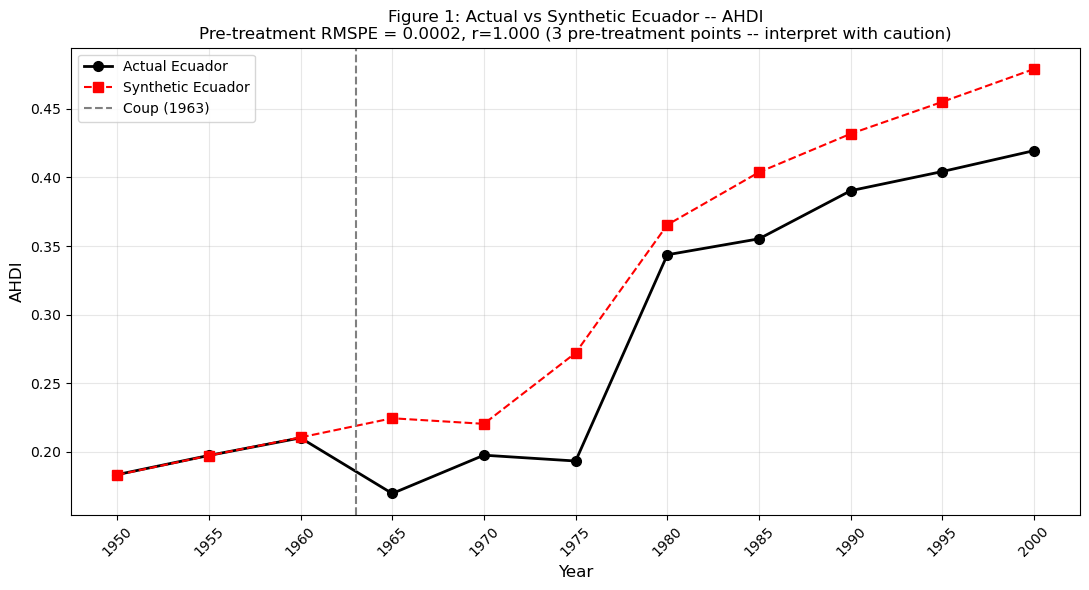

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(AHDI_ALL_YEARS_EC, actual_ec, 'k-o', markersize=7, linewidth=2,
        label='Actual Ecuador')
ax.plot(AHDI_ALL_YEARS_EC, synth_vals_ec, 'r--s', markersize=7, linewidth=1.5,
        label='Synthetic Ecuador')
ax.axvline(x=INTERVENTION_YEAR_EC, color='gray', linestyle='--',
           linewidth=1.5, label=f'Coup ({INTERVENTION_YEAR_EC})')

corr_str = f', r={corr_pre_ec:.3f}' if np.isfinite(corr_pre_ec) else ''
ax.set_title(
    f'Figure 1: Actual vs Synthetic Ecuador -- AHDI\n'
    f'Pre-treatment RMSPE = {rmspe_pre_ec:.4f}{corr_str} '
    f'(3 pre-treatment points -- interpret with caution)',
    fontsize=12
)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('AHDI', fontsize=12)
ax.set_xticks(AHDI_ALL_YEARS_EC)
ax.set_xticklabels(AHDI_ALL_YEARS_EC, rotation=45)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

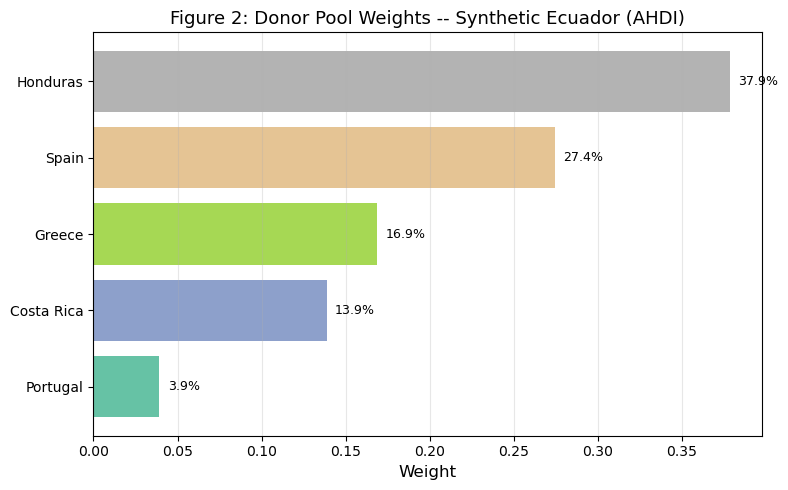

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

nonzero_w_ec = donor_weights_ec[donor_weights_ec > 0.001].sort_values()
colors_ec = plt.cm.Set2(np.linspace(0, 1, len(nonzero_w_ec)))

ax.barh(range(len(nonzero_w_ec)), nonzero_w_ec.values, color=colors_ec)
ax.set_yticks(range(len(nonzero_w_ec)))
ax.set_yticklabels(nonzero_w_ec.index, fontsize=10)
ax.set_xlabel('Weight', fontsize=12)
ax.set_title('Figure 2: Donor Pool Weights -- Synthetic Ecuador (AHDI)', fontsize=13)

for i, (c, w) in enumerate(nonzero_w_ec.items()):
    ax.text(w + 0.005, i, f'{w:.1%}', va='center', fontsize=9)

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Interpretation

The 1963 coup removed a constitutional government and installed a military junta that
governed until 1966. The AHDI gap captures the composite welfare difference relative
to a counterfactual Ecuador that continued on its pre-1963 democratic trajectory.

Ecuador's post-1963 AHDI path is complicated by two developments that are partially
orthogonal to the political treatment. First, the 1972 discovery of large Amazon oil
reserves produced a sharp income shock that elevated the income component of AHDI
from the mid-1970s onward regardless of political regime. Second, Ecuador's democratic
transition in 1966 and subsequent political instability through the 1970s means the
post-treatment period is not a clean counterfactual comparison against continued
democracy.


### Limitations

**Three pre-treatment observations.** Identical to the Dominican Republic: with 1950,
1955, and 1960 as the only pre-treatment AHDI points, the synthetic control achieves
near-perfect pre-treatment fit by construction.

**Oil boom confound.** The 1972 Amazon oil discovery introduced an AHDI income component
that would rise after 1975 regardless of governance structure, which makes the post-treatment
gap difficult to attribute to the intervention.

**Investment exclusion.** Ecuador's PWT investment share (~60%) exceeds the plausibility
threshold and is excluded from the predictor set. This means the synthetic control is
matched on GDP, human capital, and schooling only, with no investment balance.


---

## Argentina 1976

On March 24, 1976, a military junta led by General Jorge Rafael Videla overthrew
President Maria Estela Martinez de Peron, launching the Proceso de Reorganizacion
Nacional. The regime that followed was the most repressive in Argentine history:
an estimated 30,000 people were killed or disappeared between 1976 and 1983. The
junta dismantled democratic institutions, implemented IMF-aligned economic shock
therapy, and suppressed labor organizations throughout its tenure.

The freedom component of AHDI is the primary channel through which the Proceso would
be expected to depress the composite index relative to the democratic counterfactual.

In [ ]:
# Argentina 1976 case study parameters
TREATED_COUNTRY_AR = "Argentina"
INTERVENTION_YEAR_AR = 1976
PRE_TREATMENT_START_AR = 1950
PRE_TREATMENT_END_AR = 1975

# 6 pre-treatment AHDI points -- best-identified case in the notebook
AHDI_PRE_YEARS_AR  = [1950, 1955, 1960, 1965, 1970, 1975]
AHDI_POST_YEARS_AR = [1980, 1985, 1990, 1995, 2000]
AHDI_ALL_YEARS_AR  = AHDI_PRE_YEARS_AR + AHDI_POST_YEARS_AR

# Tighter GDP ceiling (175%) -- Argentina's income level is higher,
# and a 300% ceiling would include implausible structural comparators
GDP_FLOOR_AR = 0.25
GDP_CEIL_AR  = 1.75

### Donor Pool Construction

The 175% GDP ceiling reflects Argentina's 1975 per capita income of $12,946, which
is substantially higher than the other four case studies. A 300% ceiling would extend
to $39,000+ and include countries with no resemblance to Argentina. The
25%-175% window captures Colombia and Mexico at the low end and the Nordic countries
near the upper.

In [ ]:
EXCLUSIONS_AR = {
    "Argentina": "Treated country",
    "Chile": "Other treated unit",
    "Brazil": "Other treated unit",
    "Dominican Republic": "Other treated unit",
    "Ecuador": "Other treated unit",
    "Uruguay": "Bordaberry coup 1973; contemporaneous",
    "Peru": "Morales Bermudez coup August 1975; contemporaneous",
    "Bolivia": "Banzer dictatorship 1971-1978",
    "Bolivia (Plurinational State of)": "Banzer dictatorship",
    "Cuba": "Castro socialist economy",
    "Haiti": "Duvalier dictatorship",
    "Nicaragua": "Somoza dynastic rule; Sandinista revolution 1979",
    "Guatemala": "Military government; civil war",
    "El Salvador": "Military regime; civil war 1979-1992",
    "Honduras": "Lopez Arellano military; Melgar Castro coup 1975",
    "Panama": "Torrijos military from 1968",
    "Paraguay": "Stroessner dictatorship",
    "Thailand": "Military regimes",
    "Indonesia": "Suharto regime from 1965",
    "Viet Nam": "War; communist reunification 1975",
    "South Africa": "Apartheid",
    "Algeria": "One-party; nationalized",
    "Egypt": "Arab Socialism",
    "Syrian Arab Republic": "Ba'ath regime",
    "Syria": "Ba'ath regime",
    "Romania": "Communist",
    "Bulgaria": "Soviet satellite",
    "Hungary": "Soviet satellite",
    "Albania": "Communist",
    "Poland": "Soviet satellite",
    "Former Yugoslavia": "Socialist",
    "Yugoslavia": "Socialist",
    "Croatia": "Socialist Yugoslavia",
    "Slovenia": "Socialist Yugoslavia",
    "Bosnia and Herzegovina": "Post-Yugoslav",
    "Serbia": "Post-Yugoslav",
    "Montenegro": "Post-Yugoslav",
    "Macedonia": "Post-Yugoslav",
    "TFYR of Macedonia": "Post-Yugoslav",
    "Former USSR": "Soviet",
    "Russian Federation": "USSR",
    "Czechoslovakia": "Socialist",
    "Czech Republic": "Former Czechoslovakia",
    "Seychelles": "Socialist",
    "Congo": "Socialist 1969-1992",
    "Tunisia": "Single-party",
    "Yemen": "Socialist 1967-1990",
    "Venezuela (Bolivarian Republic of)": "OPEC; oil",
    "Venezuela": "OPEC; oil",
    "Libya": "Oil; Gaddafi",
    "Iran (Islamic Republic of)": "Oil; Revolution 1979",
    "Iran": "Oil",
    "Gabon": "Oil",
    "Iraq": "Oil; Ba'athist",
    "Bahrain": "Oil",
    "Saudi Arabia": "Oil",
    "Kuwait": "Oil; OPEC",
    "Trinidad and Tobago": "Oil; 1970s boom",
    "Equatorial Guinea": "Oil",
    "Oman": "Oil",
    "Nigeria": "Oil; military coups",
    "Republic of Korea": "Asian Tiger; Park/Chun military",
    "Taiwan, Province of China": "Asian Tiger",
    "Taiwan": "Asian Tiger",
    "Malaysia": "Tiger Cub",
    "Singapore": "City-state Tiger",
    "China, Hong Kong SAR": "City-state",
    "Hong Kong": "City-state",
    "Puerto Rico": "US territory",
    "Barbados": "Small island",
    "Cyprus": "Small island; 1974 partition",
    "Mauritius": "Small island",
    "Malta": "Small island",
    "Jamaica": "Manley socialism 1972-1980; IMF crisis",
    "Iceland": "Micro-economy",
    "Luxembourg": "Micro-economy",
    "Saint Lucia": "Micro-economy",
    "Dominica": "Micro-island",
    "Djibouti": "French territory",
    "Lebanon": "Civil war 1975-1990",
    "Sri Lanka": "Tamil insurgency",
    "Liberia": "Coup 1980",
    "Cambodia": "Khmer Rouge 1975-1979",
    "Sudan": "Civil war",
    "Sudan (Former)": "Civil war",
    "Angola": "Civil war",
    "Namibia": "UNITA conflict",
    "Swaziland": "ANC conflicts",
    "Palestine": "Incomplete",
    "State of Palestine": "Incomplete",
    "Jordan": "Incomplete",
    "Israel": "Yom Kippur War 1973; military spending",
    "Afghanistan": "Incomplete",
    "Benin": "Non-Atlantic",
    "Togo": "Non-Atlantic",
    "Niger": "Non-Atlantic",
    "Burkina Faso": "Non-Atlantic",
    "Mali": "Non-Atlantic",
    "Mauritania": "Non-Atlantic",
    "Gambia": "Non-Atlantic",
    "Sierra Leone": "Non-Atlantic",
    "Guinea": "Non-Atlantic",
    "Guinea-Bissau": "Non-Atlantic",
    "Côte d'Ivoire": "Non-Atlantic",
    "Cameroon": "Non-Atlantic",
    "Central African Republic": "Non-Atlantic",
    "Chad": "Non-Atlantic",
    "Uganda": "Non-Atlantic",
    "Kenya": "Non-Atlantic",
    "Tanzania": "Non-Atlantic",
    "United Republic of Tanzania": "Non-Atlantic",
    "U.R. of Tanzania: Mainland": "Non-Atlantic",
    "Zambia": "Non-Atlantic",
    "Zimbabwe": "Non-Atlantic",
    "Malawi": "Non-Atlantic",
    "Lesotho": "Non-Atlantic",
    "Rwanda": "Non-Atlantic",
    "Burundi": "Non-Atlantic",
    "Madagascar": "Non-Atlantic",
    "Ethiopia": "Non-Atlantic",
    "Somalia": "Non-Atlantic",
    "Eritrea": "Non-Atlantic",
    "Mozambique": "Non-Atlantic",
    "Ghana": "Non-Atlantic",
    "Senegal": "Non-Atlantic",
    "Botswana": "Non-Atlantic",
    "Comoros": "Non-Atlantic",
    "Democratic Republic of the Congo": "Non-Atlantic",
    "D.R. of the Congo": "Non-Atlantic",
    "Sao Tome and Principe": "Non-Atlantic",
    "Cabo Verde": "Non-Atlantic",
    "India": "Non-Atlantic; Indira Gandhi Emergency 1975-1977",
    "Pakistan": "Non-Atlantic; Zia coup 1977",
    "Nepal": "Non-Atlantic",
    "Bangladesh": "Non-Atlantic",
    "Myanmar": "Non-Atlantic",
    "Philippines": "Non-Atlantic; Marcos martial law",
    "China": "Non-Atlantic; Maoist",
    "Mongolia": "Non-Atlantic",
    "Lao People's DR": "Non-Atlantic",
}

RETAINED_NOTES_AR = {
    "Australia": "Democratic throughout; Anglo settler economy.",
    "Austria": "Democratic throughout.",
    "Belgium": "Democratic throughout.",
    "Colombia": "Democratic; key LA comparator.",
    "Costa Rica": "Democratic throughout; LA benchmark.",
    "Denmark": "Democratic throughout.",
    "Finland": "Democratic throughout.",
    "France": "Democratic throughout.",
    "Germany": "Democratic throughout.",
    "Greece": "Metapolitefsi 1974; democratic transition. LIMITATION.",
    "Ireland": "Democratic throughout; mid-income European.",
    "Italy": "Democratic throughout; Mediterranean comparator.",
    "Japan": "Democratic throughout; high-growth.",
    "Mexico": "PRI but market economy; key LA comparator.",
    "Netherlands": "Democratic throughout.",
    "New Zealand": "Democratic throughout; Anglo settler economy.",
    "Norway": "Democratic throughout.",
    "Portugal": "Carnation Revolution 1974; democratic transition. LIMITATION.",
    "Spain": "Franco died Nov 1975; democratic transition -- opposite direction to AR. LIMITATION.",
    "Sweden": "Democratic throughout.",
    "Turkey": "Democratic 1973-1980 (pre-1980 coup); missing PWT HC data. LIMITATION.",
    "United Kingdom": "Democratic throughout.",
    "Morocco": "Non-LA Atlantic comparator. LIMITATION.",
}

maddison_ar = maddison_full[
    (maddison_full["year"] >= PRE_TREATMENT_START_AR) &
    (maddison_full["year"] <= 2000)
].copy()

ar_gdp_1975 = maddison_ar.loc[
    (maddison_ar["country"] == TREATED_COUNTRY_AR) &
    (maddison_ar["year"] == PRE_TREATMENT_END_AR), "gdppc"
].values[0]

gdp_screen_ar = (
    maddison_ar[maddison_ar["year"] == PRE_TREATMENT_END_AR][['country', 'gdppc']]
    .dropna(subset=['gdppc']).copy()
)
gdp_screen_ar['ratio'] = gdp_screen_ar['gdppc'] / ar_gdp_1975

candidates_ar = gdp_screen_ar[
    (gdp_screen_ar['ratio'] >= GDP_FLOOR_AR) &
    (gdp_screen_ar['ratio'] <= GDP_CEIL_AR) &
    (~gdp_screen_ar['country'].isin(EXCLUSIONS_AR))
]['country'].tolist()

print(f"Argentina 1975 GDP: ${ar_gdp_1975:,.0f}")
print(f"Candidates after GDP screening and exclusions: {len(candidates_ar)}")

Argentina 1975 GDP: $12,946
Candidates after GDP screening and exclusions: 22


In [ ]:
maddison_required_ar = set(range(1950, 2001))
final_donor_pool_ar = []
dropped_ar = []

for c in candidates_ar:
    reasons = []

    c_ahdi = ahdi_data[
        (ahdi_data['country'] == c) & (ahdi_data['year'].isin(AHDI_ALL_YEARS_AR))
    ]
    if len(c_ahdi) < len(AHDI_ALL_YEARS_AR):
        reasons.append(f"AHDI {len(c_ahdi)}/{len(AHDI_ALL_YEARS_AR)} points")

    c_gdp = maddison_ar[
        (maddison_ar['country'] == c) & (maddison_ar['year'].isin(maddison_required_ar))
    ].dropna(subset=['gdppc'])
    if len(c_gdp) < len(maddison_required_ar):
        reasons.append(f"Maddison {len(c_gdp)}/{len(maddison_required_ar)} years")

    if reasons:
        dropped_ar.append((c, reasons))
    else:
        final_donor_pool_ar.append(c)

if dropped_ar:
    print(f"Dropped for incomplete data ({len(dropped_ar)}):")
    for c, reasons in dropped_ar:
        print(f"  {c}: {'; '.join(reasons)}")

donor_units_ar = sorted(final_donor_pool_ar)
countries_of_interest_ar = [TREATED_COUNTRY_AR] + donor_units_ar

print(f"\nFinal donor pool: {len(donor_units_ar)} countries")
for c in donor_units_ar:
    gdp_val = gdp_screen_ar.loc[gdp_screen_ar['country'] == c, 'gdppc'].values[0]
    note = f"  ({RETAINED_NOTES_AR[c]})" if c in RETAINED_NOTES_AR else ""
    print(f"  {c}: ${gdp_val:,.0f}{note}")


Final donor pool: 22 countries
  Australia: $20,993  (Democratic throughout; Anglo settler economy.)
  Austria: $18,564  (Democratic throughout.)
  Belgium: $19,831  (Democratic throughout.)
  Colombia: $5,772  (Democratic; key LA comparator.)
  Costa Rica: $7,007  (Democratic throughout; LA benchmark.)
  Denmark: $21,712  (Democratic throughout.)
  Finland: $18,237  (Democratic throughout.)
  France: $20,653  (Democratic throughout.)
  Germany: $19,193  (Democratic throughout.)
  Greece: $12,309  (Metapolitefsi 1974; democratic transition. LIMITATION.)
  Ireland: $11,662  (Democratic throughout; mid-income European.)
  Italy: $17,123  (Democratic throughout; Mediterranean comparator.)
  Japan: $18,082  (Democratic throughout; high-growth.)
  Mexico: $8,011  (PRI but market economy; key LA comparator.)
  Netherlands: $21,318  (Democratic throughout.)
  New Zealand: $19,907  (Democratic throughout; Anglo settler economy.)
  Norway: $19,560  (Democratic throughout.)
  Portugal: $10,388 

### Building the Analysis Panel

The Argentina panel spans 11 quinquennial time points (1950-2000).

In [ ]:
ahdi_subset_ar = ahdi_data[
    (ahdi_data['country'].isin(countries_of_interest_ar)) &
    (ahdi_data['year'].isin(AHDI_ALL_YEARS_AR))
].copy().rename(columns={'country': 'unit'})

madd_merge_ar = maddison_ar[
    (maddison_ar['country'].isin(countries_of_interest_ar)) &
    (maddison_ar['year'].isin(AHDI_ALL_YEARS_AR))
][['country', 'year', 'gdppc']].rename(columns={'country': 'unit'})

pwt_merge_ar = pwt_data[
    (pwt_data['country'].isin(countries_of_interest_ar)) &
    (pwt_data['year'].isin(AHDI_ALL_YEARS_AR))
][['country', 'year', 'hc', 'csh_i']].rename(columns={'country': 'unit'})

bl_merge_ar = schooling_data[
    (schooling_data['country'].isin(countries_of_interest_ar)) &
    (schooling_data['year'].isin(AHDI_ALL_YEARS_AR))
][['country', 'year', 'school_years']].rename(columns={'country': 'unit'})

panel_long_ar = (
    ahdi_subset_ar
    .merge(madd_merge_ar, on=['unit', 'year'], how='left')
    .merge(pwt_merge_ar, on=['unit', 'year'], how='left')
    .merge(bl_merge_ar, on=['unit', 'year'], how='left')
)

ar_pre_rows = panel_long_ar[
    (panel_long_ar['unit'] == TREATED_COUNTRY_AR) &
    (panel_long_ar['year'].isin(AHDI_PRE_YEARS_AR))
]
ar_inv_mean = ar_pre_rows['csh_i'].dropna().mean()
INCLUDE_INVESTMENT_AR = pd.notna(ar_inv_mean) and ar_inv_mean <= 0.45

print(f"Panel shape: {panel_long_ar.shape}")
print(f"Columns: {list(panel_long_ar.columns)}")
print(f"Argentina investment mean: {ar_inv_mean:.3f} -> {'included' if INCLUDE_INVESTMENT_AR else 'excluded'}")

Panel shape: (253, 7)
Columns: ['unit', 'year', 'ahdi', 'gdppc', 'hc', 'csh_i', 'school_years']
Argentina investment mean: 0.125 -> included


### Fitting the Synthetic Control

With six pre-treatment observations, Argentina's AHDI can be split into three
sub-period averages of two years each: 1950-1955, 1960-1965, and 1970-1975. This
mirrors the Basque Country approach and provides three level-matching constraints
alongside the trajectory-matching in `time_optimize_ssr`.

The GDP predictor is a single entry across all six pre-treatment AHDI years.

In [ ]:
pre_rows_ar = panel_long_ar[
    (panel_long_ar['unit'] == TREATED_COUNTRY_AR) &
    (panel_long_ar['year'].isin(AHDI_PRE_YEARS_AR))
]
hc_years_ar = sorted(pre_rows_ar[pre_rows_ar['hc'].notna()]['year'].tolist())
bl_years_ar = sorted(pre_rows_ar[pre_rows_ar['school_years'].notna()]['year'].tolist())
gdp_years_ar = sorted(pre_rows_ar[pre_rows_ar['gdppc'].notna()]['year'].tolist())

# Three AHDI sub-period averages across the 6 pre-treatment years
special_predictors_ar = [
    ('ahdi',         [1950, 1955], 'mean'),
    ('ahdi',         [1960, 1965], 'mean'),
    ('ahdi',         [1970, 1975], 'mean'),
    ('gdppc',        gdp_years_ar, 'mean'),
    ('hc',           hc_years_ar,  'mean'),
    ('school_years', bl_years_ar,  'mean'),
]
if INCLUDE_INVESTMENT_AR:
    inv_years_ar = sorted(pre_rows_ar[pre_rows_ar['csh_i'].notna()]['year'].tolist())
    if inv_years_ar:
        special_predictors_ar.append(('csh_i', inv_years_ar, 'mean'))

required_cols_ar = ['ahdi', 'gdppc', 'hc', 'school_years']
if INCLUDE_INVESTMENT_AR:
    required_cols_ar.append('csh_i')
donor_units_ar = [
    c for c in donor_units_ar
    if not any(
        panel_long_ar[
            (panel_long_ar['unit'] == c) &
            (panel_long_ar['year'].isin(AHDI_PRE_YEARS_AR))
        ][col].isna().all()
        for col in required_cols_ar if col in panel_long_ar.columns
    )
]

dataprep_ar = Dataprep(
    foo=panel_long_ar,
    predictors=[],
    predictors_op='mean',
    time_predictors_prior=AHDI_PRE_YEARS_AR,
    special_predictors=special_predictors_ar,
    dependent='ahdi',
    unit_variable='unit',
    time_variable='year',
    treatment_identifier=TREATED_COUNTRY_AR,
    controls_identifier=donor_units_ar,
    time_optimize_ssr=AHDI_PRE_YEARS_AR,
)

synth_ar = Synth()
synth_ar.fit(dataprep=dataprep_ar, optim_method='Nelder-Mead', optim_initial='equal')

weights_raw_ar = synth_ar.weights(round=4)
if isinstance(weights_raw_ar, pd.Series):
    w_dict_ar = weights_raw_ar.to_dict()
elif isinstance(weights_raw_ar, pd.DataFrame):
    w_dict_ar = {row.iloc[0]: float(row.iloc[1]) for _, row in weights_raw_ar.iterrows()}
else:
    w_dict_ar = {donor_units_ar[k]: float(weights_raw_ar[k]) for k in range(len(donor_units_ar))}

donor_weights_ar = pd.Series(w_dict_ar).sort_values(ascending=False)
nonzero_ar = donor_weights_ar[donor_weights_ar > 0.001]
print('Donor weights (nonzero):')
for c, w in nonzero_ar.items():
    print(f'  {c}: {w:.4f} ({w*100:.1f}%)')
print(f'Weight sum: {donor_weights_ar.sum():.4f}')

Donor weights (nonzero):
  Greece: 0.5086 (50.9%)
  Mexico: 0.3492 (34.9%)
  New Zealand: 0.1422 (14.2%)
Weight sum: 1.0000


### Pre-treatment Fit

With six pre-treatment observations across a 25-year window, Argentina's synthetic
control has substantially more trajectory information than the three-point cases.


In [ ]:
outcome_panel_ar = panel_long_ar.pivot_table(
    index='year', columns='unit', values='ahdi'
).reindex(AHDI_ALL_YEARS_AR)

actual_ar = outcome_panel_ar[TREATED_COUNTRY_AR].values

synth_vals_ar = np.zeros(len(AHDI_ALL_YEARS_AR))
for c, w in w_dict_ar.items():
    if w > 1e-6 and c in outcome_panel_ar.columns:
        synth_vals_ar += w * outcome_panel_ar.loc[AHDI_ALL_YEARS_AR, c].values

gap_ar = actual_ar - synth_vals_ar

pre_idx_ar  = [i for i, y in enumerate(AHDI_ALL_YEARS_AR) if y in AHDI_PRE_YEARS_AR]
post_idx_ar = [i for i, y in enumerate(AHDI_ALL_YEARS_AR) if y in AHDI_POST_YEARS_AR]
pre_actual_ar = actual_ar[pre_idx_ar]
pre_synth_ar  = synth_vals_ar[pre_idx_ar]

rmspe_pre_ar = np.sqrt(np.mean((pre_actual_ar - pre_synth_ar) ** 2))
corr_pre_ar  = np.corrcoef(pre_actual_ar, pre_synth_ar)[0, 1] if len(pre_actual_ar) > 2 else np.nan
avg_gap_post_ar = np.mean(gap_ar[post_idx_ar])

print(f"{'Year':>6}  {'Actual':>8}  {'Synthetic':>9}  {'Gap':>8}  {'Period':>6}")
print('-' * 50)
for i, y in enumerate(AHDI_ALL_YEARS_AR):
    period = 'PRE' if y in AHDI_PRE_YEARS_AR else 'POST'
    print(f"{y:>6}  {actual_ar[i]:>8.4f}  {synth_vals_ar[i]:>9.4f}  {gap_ar[i]:>+8.4f}  {period:>6}")

print(f"\nPre-treatment RMSPE:       {rmspe_pre_ar:.6f}")
if np.isfinite(corr_pre_ar):
    print(f"Pre-treatment correlation: {corr_pre_ar:.4f}")
print(f"Avg post-treatment gap:    {avg_gap_post_ar:+.4f} AHDI units")

  Year    Actual  Synthetic       Gap  Period
--------------------------------------------------
  1950    0.2768     0.2580   +0.0188     PRE
  1955    0.2723     0.2845   -0.0122     PRE
  1960    0.3344     0.3012   +0.0332     PRE
  1965    0.3381     0.3209   +0.0172     PRE
  1970    0.2536     0.2801   -0.0265     PRE
  1975    0.3653     0.3957   -0.0304     PRE
  1980    0.2365     0.4262   -0.1897    POST
  1985    0.4600     0.4510   +0.0090    POST
  1990    0.4551     0.4811   -0.0260    POST
  1995    0.4806     0.5162   -0.0356    POST
  2000    0.4968     0.5586   -0.0618    POST

Pre-treatment RMSPE:       0.024246
Pre-treatment correlation: 0.8407
Avg post-treatment gap:    -0.0608 AHDI units


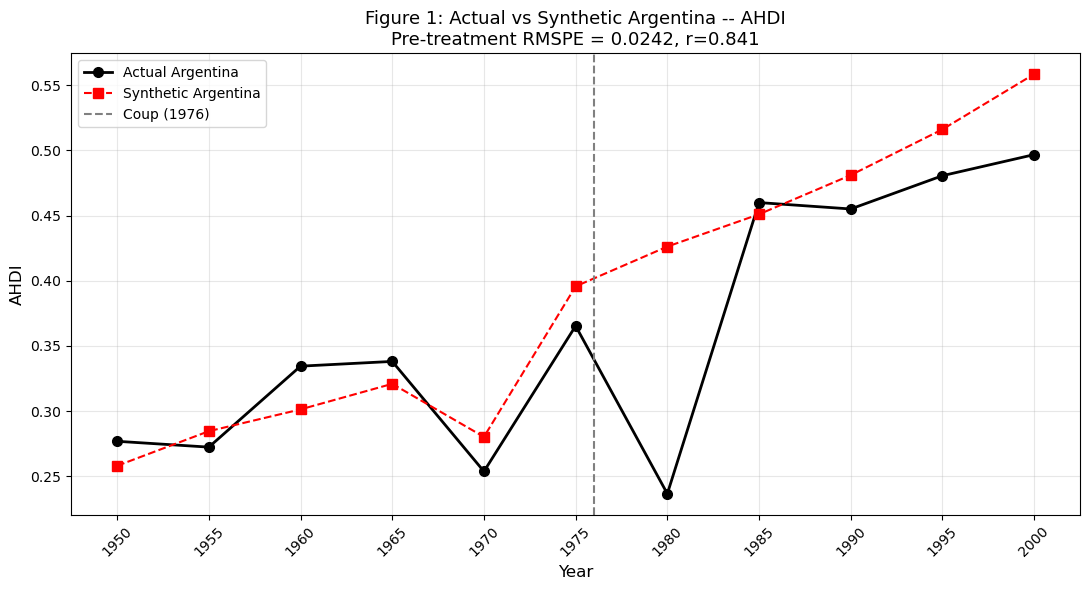

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(AHDI_ALL_YEARS_AR, actual_ar, 'k-o', markersize=7, linewidth=2,
        label='Actual Argentina')
ax.plot(AHDI_ALL_YEARS_AR, synth_vals_ar, 'r--s', markersize=7, linewidth=1.5,
        label='Synthetic Argentina')
ax.axvline(x=INTERVENTION_YEAR_AR, color='gray', linestyle='--',
           linewidth=1.5, label=f'Coup ({INTERVENTION_YEAR_AR})')

corr_str = f', r={corr_pre_ar:.3f}' if np.isfinite(corr_pre_ar) else ''
ax.set_title(
    f'Figure 1: Actual vs Synthetic Argentina -- AHDI\n'
    f'Pre-treatment RMSPE = {rmspe_pre_ar:.4f}{corr_str}',
    fontsize=13
)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('AHDI', fontsize=12)
ax.set_xticks(AHDI_ALL_YEARS_AR)
ax.set_xticklabels(AHDI_ALL_YEARS_AR, rotation=45)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

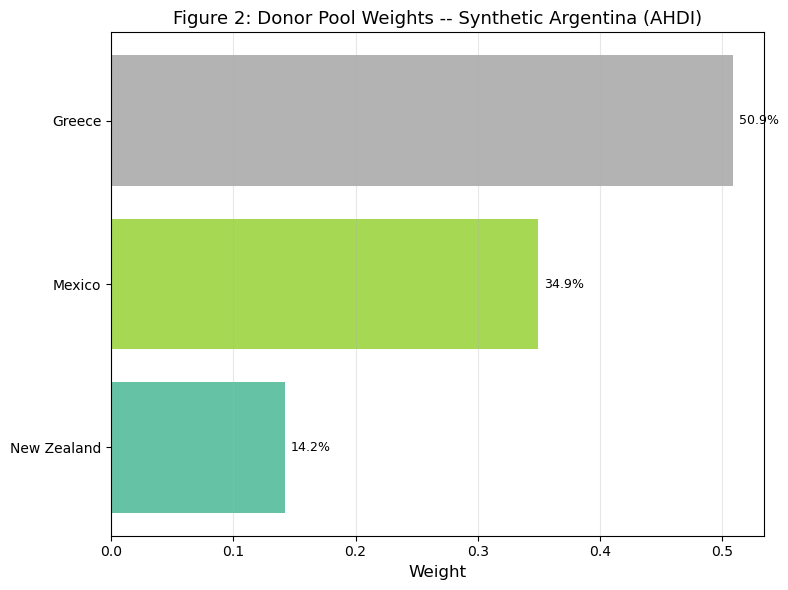

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

nonzero_w_ar = donor_weights_ar[donor_weights_ar > 0.001].sort_values()
colors_ar = plt.cm.Set2(np.linspace(0, 1, len(nonzero_w_ar)))

ax.barh(range(len(nonzero_w_ar)), nonzero_w_ar.values, color=colors_ar)
ax.set_yticks(range(len(nonzero_w_ar)))
ax.set_yticklabels(nonzero_w_ar.index, fontsize=10)
ax.set_xlabel('Weight', fontsize=12)
ax.set_title('Figure 2: Donor Pool Weights -- Synthetic Argentina (AHDI)', fontsize=13)

for i, (c, w) in enumerate(nonzero_w_ar.items()):
    ax.text(w + 0.005, i, f'{w:.1%}', va='center', fontsize=9)

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Interpretation

The Proceso de Reorganizacion Nacional (1976-1983) combined systematic political
repression with a monetarist economic program that produced severe inflation and
deindustrialization. The AHDI gap for Argentina captures the composite welfare
effect of these concurrent processes. The freedom component fell sharply from
the suppression of political rights, while the income component reflects the
economic disruption of the early Proceso years followed by partial recovery under
the Falklands-era government.

Argentina's raw AHDI shows a notable decline from 0.365 in 1975 to 0.237 in 1980,
followed by a recovery to 0.460 by 1985. This trajectory likely represents the combination
of the 1978-1982 economic crisis and the partial political opening following the Falklands War
(1982) and the return to democracy in 1983. The synthetic counterfactual asks how
much of this trough was attributable to the coup rather than other factors.


### Limitations

**Pre-treatment political instability.** Argentina experienced prior coups in 1955,
1962, and 1966, all of which affect the pre-treatment AHDI trajectory. The synthetic
control matches Argentina's actual pre-treatment path including these disruptions.
The 1976 treatment estimate therefore captures the marginal effect of the Proceso
relative to Argentina's already volatile political baseline.

**Donor pool asymmetry.** Most donors in the 21-country pool are stable OECD
democracies that were on a smooth upward welfare trajectory through the 1970s. This
makes Argentina's pre-treatment volatility harder to match and may cause the
synthetic control to underfit the 1970 dip in Argentina's AHDI.

**Democratic transition confound.** Spain, Portugal, and Greece all underwent
democratic transitions in 1974-1975, roughly concurrent with Argentina's
pre-treatment endpoint. Their post-1976 AHDI growth reflects a democratic opening
that is the opposite of Argentina's political trajectory. Including them in the
donor pool creates a structural asymmetry in the post-treatment period.

**Short post-treatment window.** With only five post-treatment AHDI observations
(1980-2000), there are limited time points for measuring the Proceso's welfare
effects. The 1983 democratic transition and subsequent Menem-era reforms fall within
this window, making it difficult to isolate the Proceso's effects from the subsequent
political and economic changes.

### Conclusions

The AHDI results tell a more consistent story than the GDP per capita findings do. In every country studied, the Augmented Human Development Index declined at the first observation following the military intervention, driven primarily by the collapse of the civil and political freedom component that GDP does not capture. Chile shows the sharpest drop, falling nearly 45 percent between 1970 and 1975, but Brazil, Ecuador, the Dominican Republic, and Argentina all register immediate declines relative to their synthetic counterfactuals as well. This is striking given how different the GDP results look across cases. Brazil's actual GDP eventually outperformed its counterfactual while Chile's and Argentina's fell well below, yet all five countries saw their AHDI fall after the coup. The inclusion of liberal democracy as one of the AHDI's four equally weighted components means that any military takeover will reduce the index through the freedom channel, suggesting the suppression of political rights is a defining feature of military rule. Recovery patterns vary. Chile's AHDI rebounds sharply after 1990 and surpasses the synthetic, while other countries show slower convergence. But the initial negative shock appears in every case. The fact that this finding holds across five countries spanning two decades of Cold War interventions, each with different economic structures, policy environments, and donor pools, offers stronger evidence for the human development costs of military coups than any individual case could provide on its own.